In [5]:
from generate_subsequences import simulate_sequences
import scripts.simulation.rank_correlation as rs
import numpy as np
import pickle
import matplotlib.pyplot as plt
nrm = np.load("scripts/simulation/nrm.npy")
import scripts.simulation.rank_correlation as rs 
from scripts.simulation.correlation_mean import add_within_clust_score

In [2]:
# PARAMETERS
params = {
    "n_neurons": 100,
    "n_motifs": 20,
    "n_bins": 100,
    "n_sequences": 100,
    "n_assemblies": 20, 
    "n_a_motifs": 20, 
    "n_a_seqs": 100,
    "sigma_range": (1, 1),    # increasing range makes sequences less similar
    "vol_param": (0.07, 0.9),     # beta distribution:  0.07, 0.9
                                  # a inactive (lower -> more neurons inactive, if high longer seqs, mean len shifts)
                                  # b active (lower -> more neurons active, if <1, skewed to 1, if lower longer seqs, mean len shifts)
    "sig_a": (1, 1),
    "vol_a":(0.1, 0.3),
    "corr_mu": False,
    "rho_mu": 0.0,
    "corr_sigma": False,
    "rho_sig": 0.0,
    "corr_volume": False,
    "rho_vol": 0.0,
    "shuffle_order": False,       # shuffle order of sequences
}

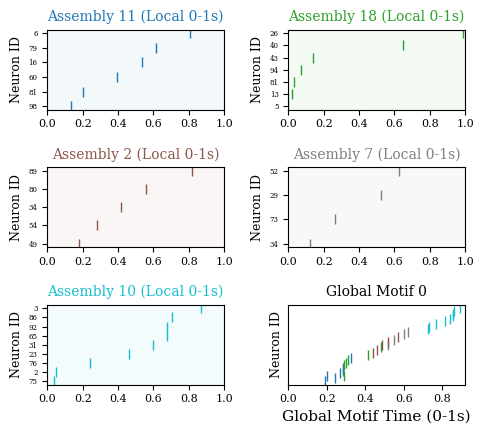

In [3]:
offset_seqs, seqs_labels, spk_times, sequences, offset_true_templates, mu, sigma, volume, densities, cdfs, assembly_n_seq, assembly_n_spk, assembly_n_labels, subsequences_dict, subspike_times, raw_assembly_neurons_seq = simulate_sequences(**params, random_state=1, plot=False, return_subsequences=True)

In [49]:
import matplotlib.pyplot as plt

# --- FLATTENING LOGIC ---
flat_a_n_seq = []
flat_a_seq = []
flat_a_n_spk = []

for a_id, motifs in sorted(subsequences_dict.items()):
    master_neuron_list = []
    master_index_list = []
    master_spike_list = []
    
    for seq_idx, m in enumerate(motifs):
        current_spike_times = subspike_times[a_id][seq_idx]
        sorted_m = sorted(m, key=lambda a: current_spike_times[a][0] if len(current_spike_times[a]) > 0 else float('inf'))
        
        L = len(sorted_m)
        if L == 0:
            continue
            
        window = 1.0 / L  
        
        for a in sorted_m:
            master_index_list.append(a)
            
            if a < len(seqs):
                sequence = seqs[a]
                
                # GET TRUE ASSEMBLY SPIKE TIME
                if len(current_spike_times[a]) > 0:
                    assembly_time = current_spike_times[a][0]
                else:
                    assembly_time = 0.0
                
                # CALCULATE WINDOW START
                if L == 1:
                    start_time = 0.0
                else:
                    # Calculate the ideal centered start time
                    ideal_start = assembly_time - (window / 2)
                    
                    # 1. Bump it right if it goes below 0.0
                    start_time = max(0.0, ideal_start)
                    
                    # 2. Bump it left if the window pushes past 1.0
                    start_time = min(start_time, 1.0 - window)
                
                # --- THE FIX: Loop specifically through the active neurons ---
                for neuron_id in sequence:
                    # Append the neuron
                    master_neuron_list.append(neuron_id)
                    
                    # Fetch ONLY the spike array belonging to this specific neuron
                    neuron_spikes = spk_times[a][neuron_id]
                    
                    # Scale them
                    scaled_spikes = [start_time + (t * window) for t in neuron_spikes]
                    
                    # Append strictly this neuron's spikes to the master list
                    master_spike_list.append(scaled_spikes)

    flat_a_n_seq.append(master_neuron_list)
    flat_a_seq.append(master_index_list)
    flat_a_n_spk.append(master_spike_list)


In [90]:
import numpy as np

## TAKE THE AVERGAE NEURON SPIKE TIMES WITHIN A SEQUENCE
# These will now be simple 2D lists: [ [seq1], [seq2], [seq3]... ]
flat_occ_n_seq = []
flat_occ_n_spk = []
flat_occ_labels = [] 

for a_id, motifs in sorted(subsequences_dict.items()):
    
    for seq_idx, m in enumerate(motifs):
        current_spike_times = subspike_times[a_id][seq_idx]
        sorted_m = sorted(m, key=lambda a: current_spike_times[a][0] if len(current_spike_times[a]) > 0 else float('inf'))
        
        L = len(sorted_m)
        if L == 0:
            # If the occurrence is completely empty, you can either append [] or skip it.
            # I am appending [] to maintain alignment, but you can change this to 'continue' if you want to drop empty sequences.
            flat_occ_n_seq.append([])
            flat_occ_n_spk.append([])
            flat_occ_labels.append(a_id)
            continue
            
        window = 1.0 / L  
        occurrence_dict = {}
        
        for a in sorted_m:
            if a < len(seqs):
                sequence = seqs[a]
                assembly_time = current_spike_times[a][0] if len(current_spike_times[a]) > 0 else 0.0
                
                # Smart window bumping
                if L == 1:
                    start_time = 0.0
                else:
                    ideal_start = assembly_time - (window / 2)
                    start_time = max(0.0, ideal_start)
                    start_time = min(start_time, 1.0 - window) 
                
                for neuron_id in sequence:
                    neuron_spikes = spk_times[a][neuron_id]
                    scaled_spikes = [start_time + (t * window) for t in neuron_spikes]
                    
                    if neuron_id not in occurrence_dict:
                        occurrence_dict[neuron_id] = []
                    occurrence_dict[neuron_id].extend(scaled_spikes)
                    
        # Deduplicate and calculate mean for this occurrence
        unique_neurons = []
        mean_spikes = []
        
        for neuron, all_spikes in occurrence_dict.items():
            if len(all_spikes) > 0:
                unique_neurons.append(neuron)
                mean_spikes.append([np.mean(all_spikes)]) 
                
        # Sort chronologically and append DIRECTLY to the master lists
        if len(unique_neurons) > 0:
            sorted_pairs = sorted(zip(unique_neurons, mean_spikes), key=lambda x: x[1][0])
            sorted_neurons, sorted_mean_spikes = zip(*sorted_pairs)
            
            flat_occ_n_seq.append(list(sorted_neurons))
            flat_occ_n_spk.append(list(sorted_mean_spikes))
            flat_occ_labels.append(a_id)
        else:
            flat_occ_n_seq.append([])
            flat_occ_n_spk.append([])
            flat_occ_labels.append(a_id)

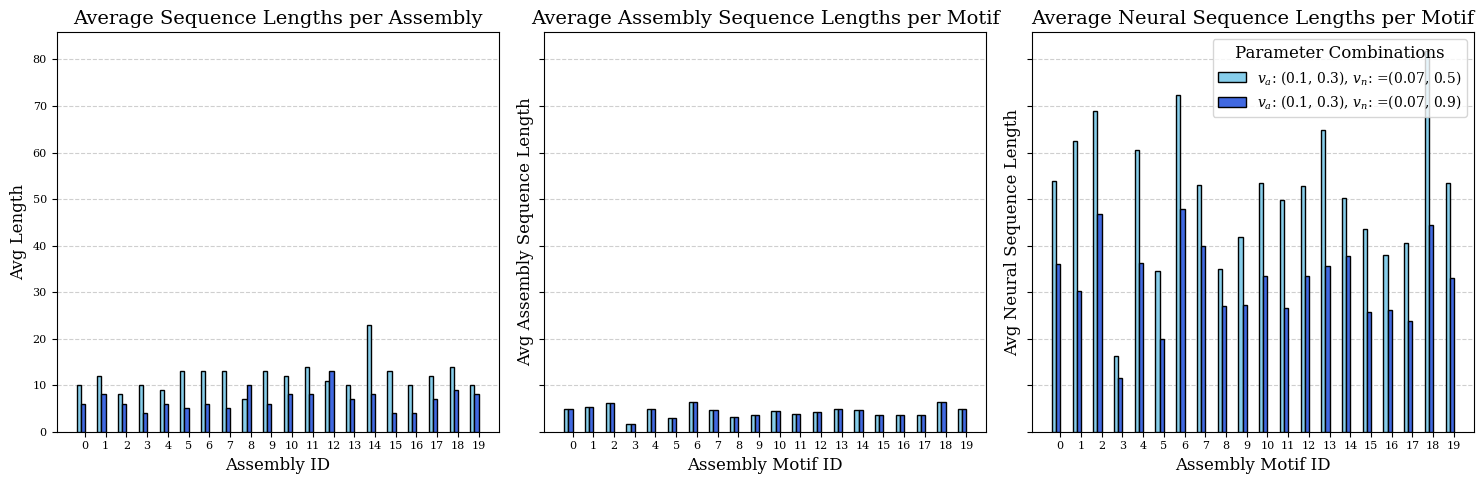

In [4]:
import matplotlib.pyplot as plt

# 1. Find all unique motif IDs across all runs to ensure the X-axis aligns perfectly
all_motifs = set()
all_motifs = subsequences_dict.keys()

combo_names = list(avg_n_lengths.keys())
x = np.arange(len(all_motifs))
width = 0.2  # Width of the bars (adjusted to fit 4 combos side-by-side)

# Create a figure with 2 subplots (Assemblies on top, Neurons on bottom)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

# Distinct colors for the 4 different parameter combinations
colors = ['skyblue', 'royalblue', 'lightgreen', 'forestgreen']

# --- Plot 1: Average Assembly Lengths (Top) ---
for i, combo_name in enumerate(combo_names):
    # Safely get the assembly averages for this combo, default to 0 if a motif is missing
    a_data = [avg_a_seq_lengths[combo_name].get(m, 0) for m in all_motifs]
    
    # Calculate offset so the 4 bars sit neatly next to each other
    offset = (i - 1.5) * width 
    axes[1].bar(x + offset, a_data, width, label=combo_name, color=colors[i], edgecolor='black', zorder=3)

axes[1].set_title('Average Assembly Sequence Lengths per Motif', fontsize=14)
axes[1].set_ylabel('Avg Assembly Sequence Length', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.6, zorder=0)
axes[1].set_xlabel('Assembly Motif ID', fontsize=12)

# --- Plot 2: Average Neuron Lengths (Bottom) ---
for i, combo_name in enumerate(combo_names):
    # Safely get the neuron averages for this combo
    n_data = [avg_n_lengths[combo_name].get(m, 0) for m in all_motifs]
    
    offset = (i - 1.5) * width 
    axes[2].bar(x + offset, n_data, width, label=combo_name, color=colors[i], edgecolor='black', zorder=3)

axes[2].set_title('Average Neural Sequence Lengths per Motif', fontsize=14)
axes[2].set_ylabel('Avg Neural Sequence Length', fontsize=12)
axes[2].set_xlabel('Assembly Motif ID', fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(all_motifs)
axes[2].grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

for i, combo_name in enumerate(combo_names):
    # Safely get the neuron averages for this combo
    as_data = [avg_a_lengths[combo_name].get(m, 0) for m in all_motifs]
    
    offset = (i - 1.5) * width 
    axes[0].bar(x + offset, as_data, width, label=combo_name, color=colors[i], edgecolor='black', zorder=3)

axes[0].set_title('Average Sequence Lengths per Assembly', fontsize=14)
axes[0].set_ylabel('Avg Length', fontsize=12)
axes[0].set_xlabel('Assembly ID', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_motifs)
axes[2].legend(title="Parameter Combinations", loc='upper right')
axes[0].grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

plt.tight_layout()
#plt.savefig(f'subseq_lengths_avol_{params["vol_a"]}.jpg', dpi = 300)
#plt.savefig(f'subseq_lengths_avol_{params["vol_a"]}.pdf', dpi = 300)
plt.show()

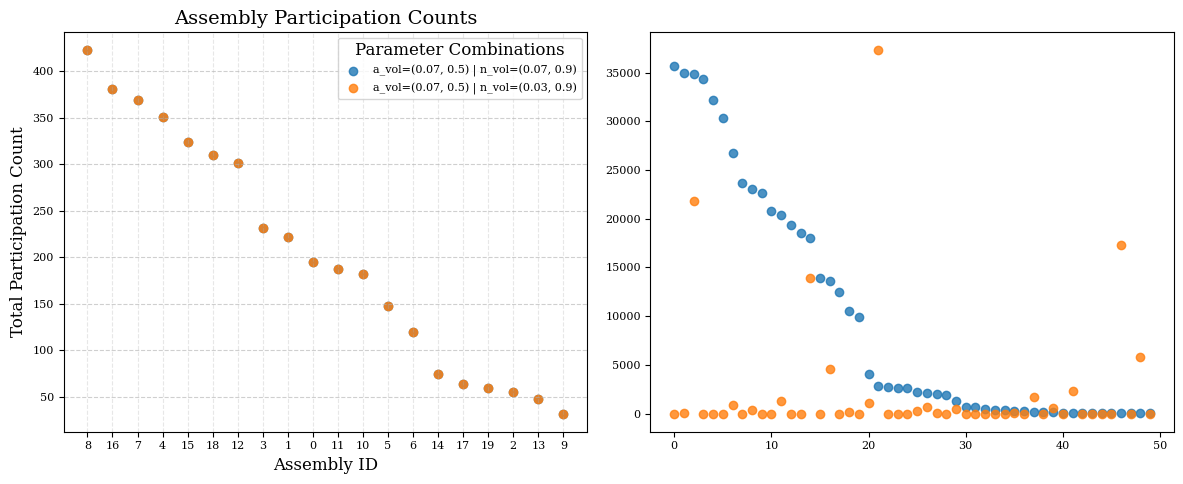

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# We use the same 4 highly distinct colors from the previous plot
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
combo_names = list(assembly_counts.keys())

target_x = assembly_counts['a_vol=(0.07, 0.5) | n_vol=(0.07, 0.9)']
sorted_assembly_ids = sorted(target_x.keys(), key=lambda x: target_x[x], reverse=True)
x_positions = np.arange(len(sorted_assembly_ids))

target_x_ns = neuron_counts['a_vol=(0.07, 0.5) | n_vol=(0.07, 0.9)']
sorted_neuron_ids = sorted(target_x_ns.keys(), key=lambda x: target_x_ns[x], reverse=True)
x_positions_n = np.arange(len(sorted_neuron_ids))

fig, ax = plt.subplots(1,2, figsize=(12, 5))

for i, combo_name in enumerate(combo_names):
    y_values_a = [assembly_counts[combo_name].get(aid, 0) for aid in sorted_assembly_ids]
    y_values_n = [neuron_counts[combo_name].get(nid, 0) for nid in sorted_neuron_ids]
    
    # Plot Assemblies (Top)
    ax[0].scatter(x_positions, y_values_a, label=combo_name, color=colors[i], alpha=0.8)
    
    # Plot Neurons (Bottom)
    ax[1].scatter(x_positions_n, y_values_n, label=combo_name, color=colors[i], alpha=0.8)

# Add formatting and labels
ax[0].set_title('Assembly Participation Counts', fontsize=14)
ax[0].set_xlabel('Assembly ID', fontsize=12)
ax[0].set_ylabel('Total Participation Count', fontsize=12)
ax[0].set_xticks(x_positions)
ax[0].set_xticklabels(sorted_assembly_ids)

# Add a grid for readability
ax[0].grid(axis='y', linestyle='--', alpha=0.6)
ax[0].grid(axis='x', linestyle='--', alpha=0.3)
ax[0].legend(title="Parameter Combinations", fontsize=8)

plt.tight_layout()
#plt.savefig('assemblyparticipation.jpg', dpi=300)
plt.show()

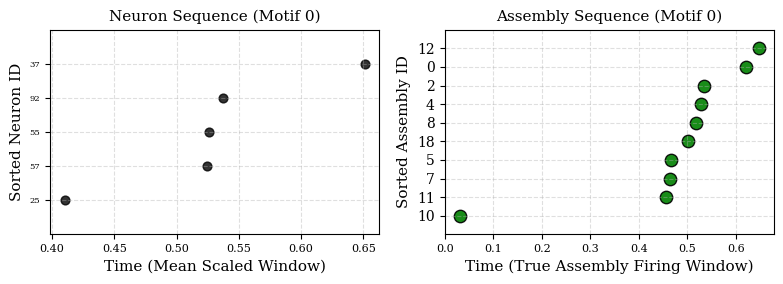

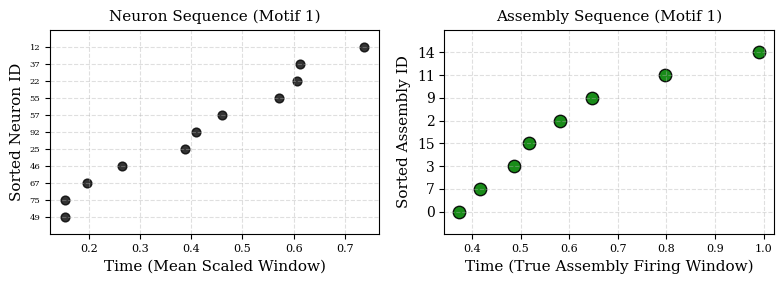

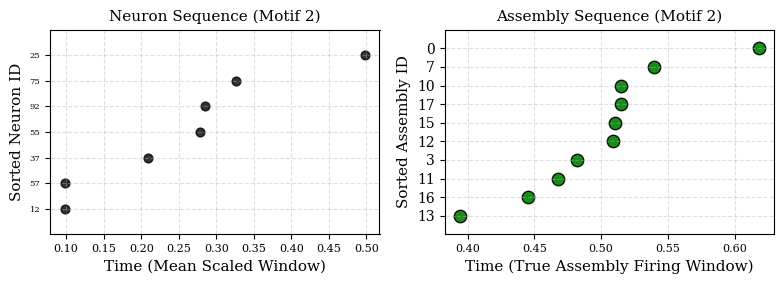

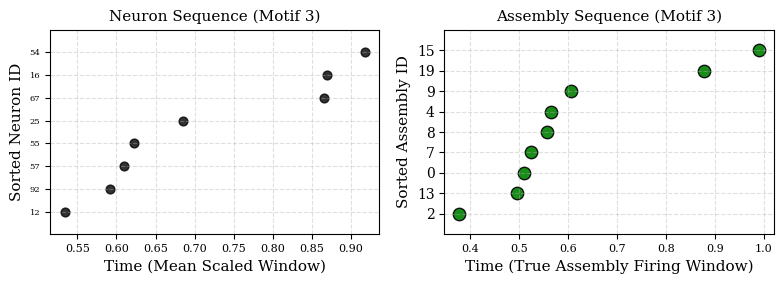

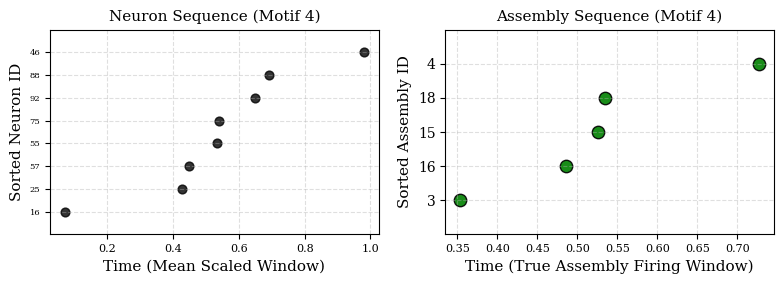

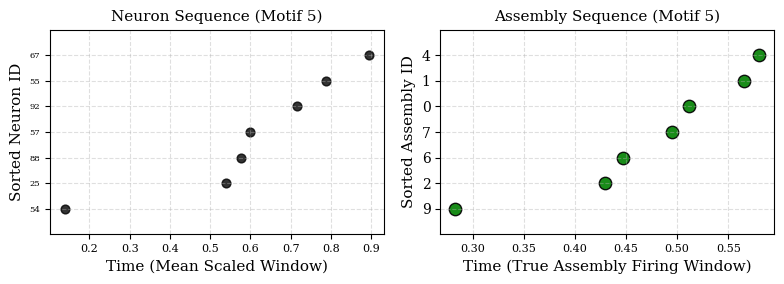

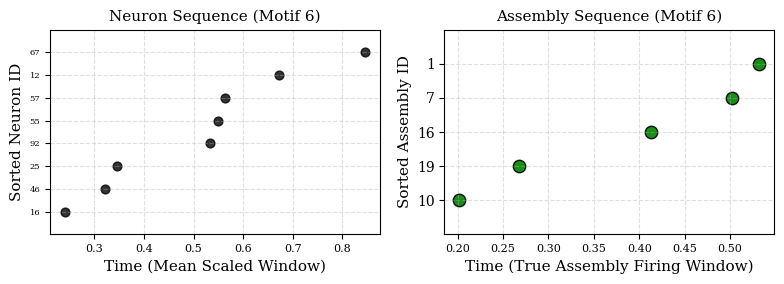

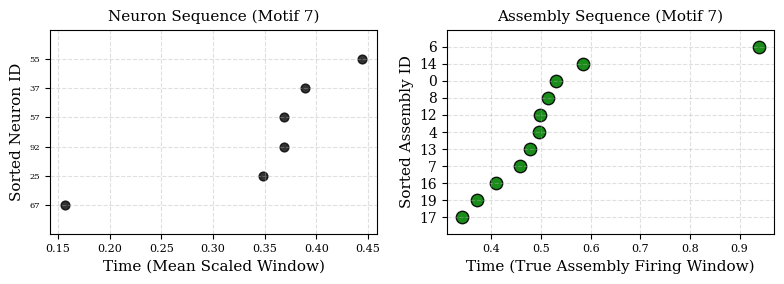

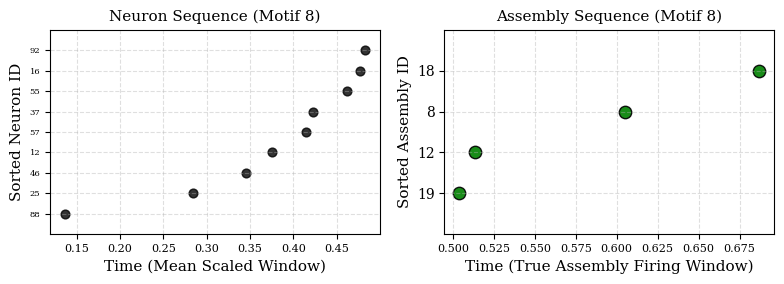

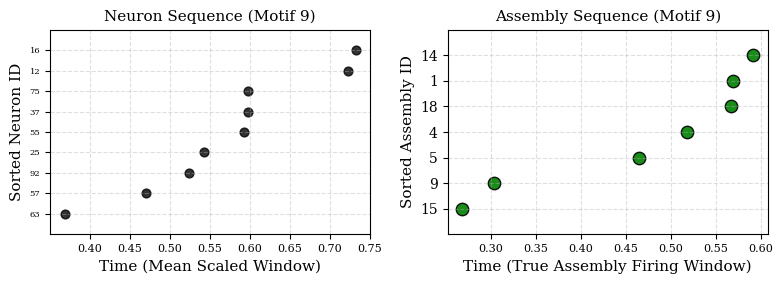

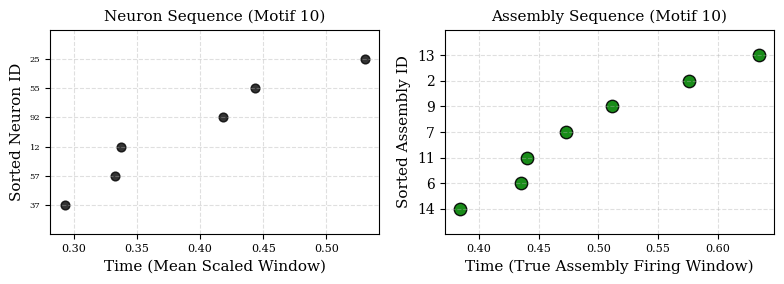

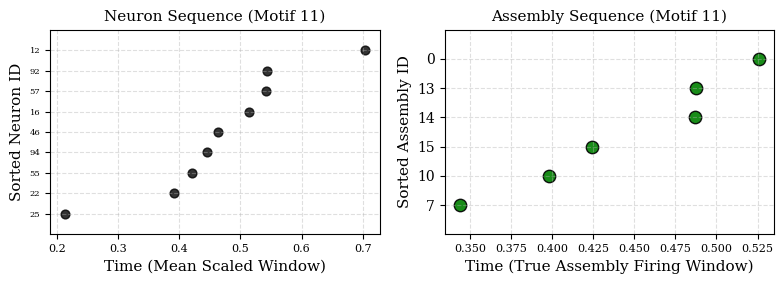

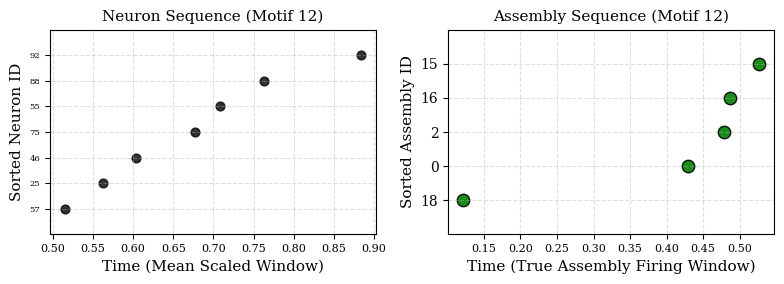

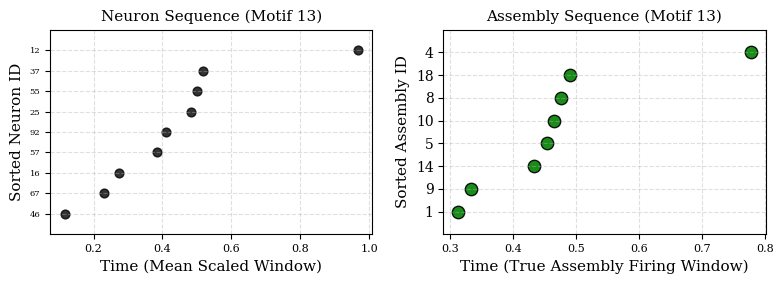

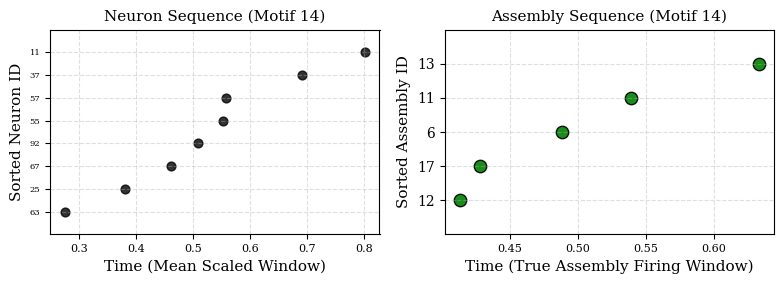

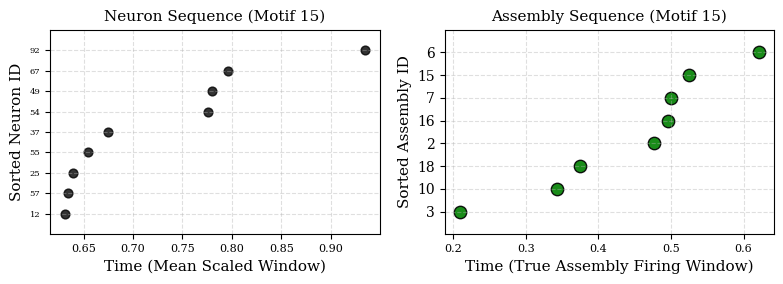

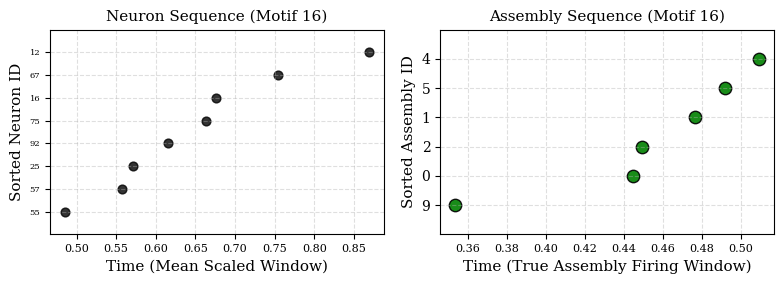

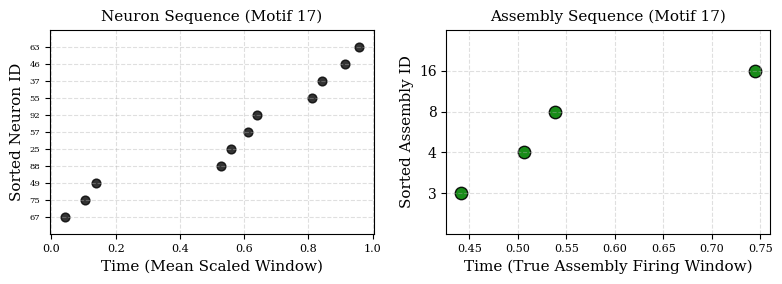

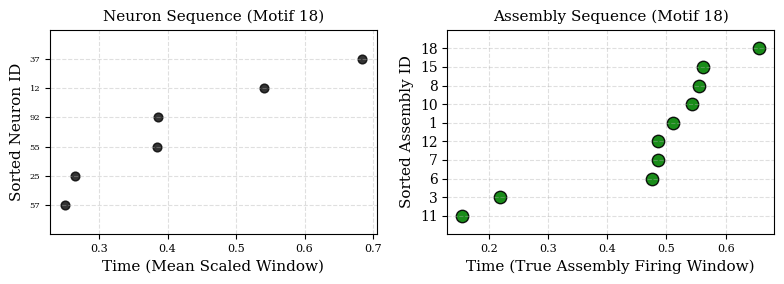

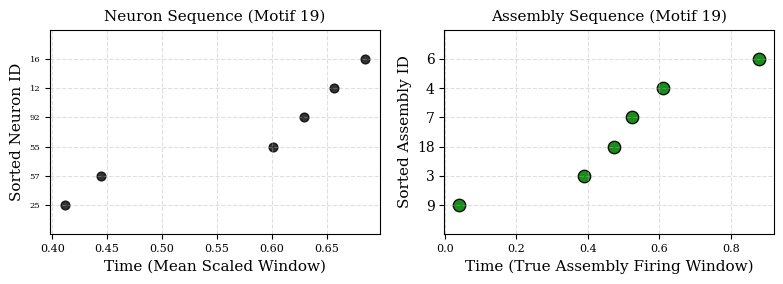

IndexError: list index out of range

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# We need the original motif IDs to fetch the raw assembly spike times
a_ids = list(sorted(subsequences_dict.keys()))

for motif_idx in range(len(assembly_n_seq)):
    # --- 1. LEFT COLUMN PREP: NEURONS ---
    neuron_ids = assembly_n_seq[motif_idx]
    neuron_spike_times = assembly_n_spk[motif_idx]
    
    total_neuron_spikes = sum(len(spikes) for spikes in neuron_spike_times)
    if total_neuron_spikes == 0:
        continue # Skip empty motifs
        
    # --- 2. RIGHT COLUMN PREP: ASSEMBLIES ---
    a_id = a_ids[motif_idx]
    motifs = subsequences_dict[a_id]
    
    # Pool assembly spikes
    assembly_spikes_dict = {}
    for seq_idx, m in enumerate(motifs):
        current_spike_times = subspike_times[a_id][seq_idx]
        for a in m:
            if len(current_spike_times[a]) > 0:
                time = current_spike_times[a][0]
                if a not in assembly_spikes_dict:
                    assembly_spikes_dict[a] = []
                assembly_spikes_dict[a].append(time)
                
    # Compute mean and sort
    unique_assemblies = []
    mean_a_spikes = []
    for a, times in assembly_spikes_dict.items():
        if len(times) > 0:
            unique_assemblies.append(a)
            mean_a_spikes.append([np.mean(times)]) # Wrapped in list for scatter plot
            
    # Sort assemblies chronologically
    if len(unique_assemblies) > 0:
        sorted_pairs = sorted(zip(unique_assemblies, mean_a_spikes), key=lambda x: x[1][0])
        sorted_assemblies, sorted_a_times = zip(*sorted_pairs)
    else:
        sorted_assemblies, sorted_a_times = [], []

    # --- 3. PLOTTING ---
    # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    
    # --- PLOT NEURONS (Left) ---
    ax_n = axes[0]
    for rank, (neuron, spikes) in enumerate(zip(neuron_ids, neuron_spike_times)):
        if len(spikes) > 0:
            ax_n.scatter(spikes, [rank] * len(spikes), color='black', s=40, alpha=0.8, edgecolors='black')
            
    ax_n.set_title(f"Neuron Sequence (Motif {motif_idx})")
    ax_n.set_xlabel("Time (Mean Scaled Window)")
    ax_n.set_ylabel("Sorted Neuron ID")
    
    if len(neuron_ids) > 0:
        ax_n.set_yticks(range(len(neuron_ids)))
        ax_n.set_yticklabels(neuron_ids, fontsize=6)
        ax_n.set_ylim(-1, len(neuron_ids))
    ax_n.grid(axis='both', linestyle='--', alpha=0.4)

    # --- PLOT ASSEMBLIES (Right) ---
    ax_a = axes[1]
    for rank, (assembly, spikes) in enumerate(zip(sorted_assemblies, sorted_a_times)):
        if len(spikes) > 0:
             # Using green for assemblies to distinguish them
             ax_a.scatter(spikes, [rank] * len(spikes), color='green', s=80, alpha=0.9, edgecolors='black')
             
    ax_a.set_title(f"Assembly Sequence (Motif {motif_idx})")
    ax_a.set_xlabel("Time (True Assembly Firing Window)")
    ax_a.set_ylabel("Sorted Assembly ID")
    
    if len(sorted_assemblies) > 0:
        ax_a.set_yticks(range(len(sorted_assemblies)))
        ax_a.set_yticklabels(sorted_assemblies, fontsize=10)
        ax_a.set_ylim(-1, len(sorted_assemblies))
    ax_a.grid(axis='both', linestyle='--', alpha=0.4)
    
    # Clean up layout so labels don't overlap, then show
    plt.tight_layout()
    #plt.savefig("timeraster.jpg", dpi=300)
    plt.show()

In [6]:
flattened_ids = []

for motif_id in subsequences_dict:
    for seq in subsequences_dict[motif_id]:
        for assembly_id in seq:
            flattened_ids.append(assembly_id)

In [23]:
rep_index, nsig, pval, bmat, zmat, corrmat = rs.allmot(assembly_n_seq, nrm)

In [ ]:
data_c = 'Correlation '
data_z = 'Z-'

plt.figure(figsize=(7, 5))
plt.imshow(zmat, aspect='auto', cmap='RdBu_r')
plt.colorbar(label=f'{data_z}Score')
plt.title(f'Neural Sequence Params: sig={params['sigma_range']} | vol={params['vol_param']}\nAssembly Sequence Params: sig={params['sig_a']} | vol={params['vol_a']}')
plt.savefig(f'subseq_zmat_N100_{params['sigma_range']}_{params['vol_param']}_A20_{params['sig_a']}_{params['vol_a']}.jpg', dpi = 300)
plt.savefig(f'subseq_zmat_N100_{params['sigma_range']}_{params['vol_param']}_A20_{params['sig_a']}_{params['vol_a']}.pdf', dpi = 300)

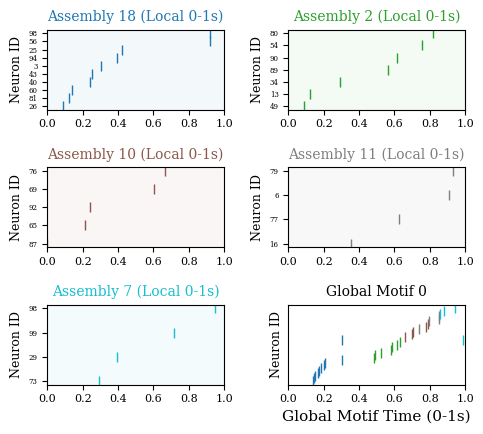

Done: (0.02, 0.2), (0.02, 0.4)


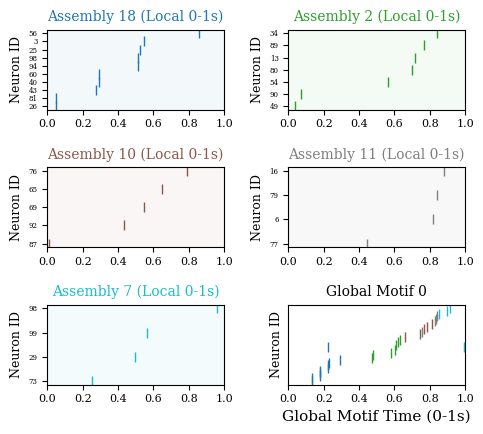

Done: (0.02, 0.2), (1, 1)


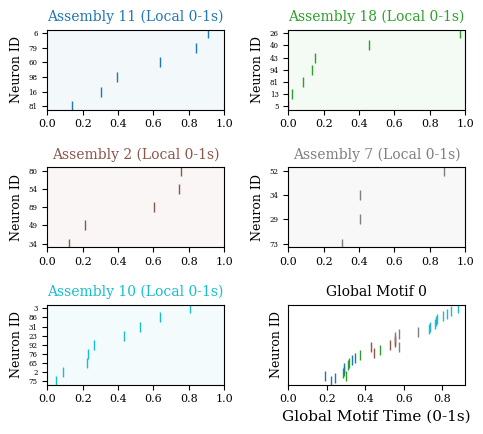

Done: (1, 1), (0.02, 0.4)


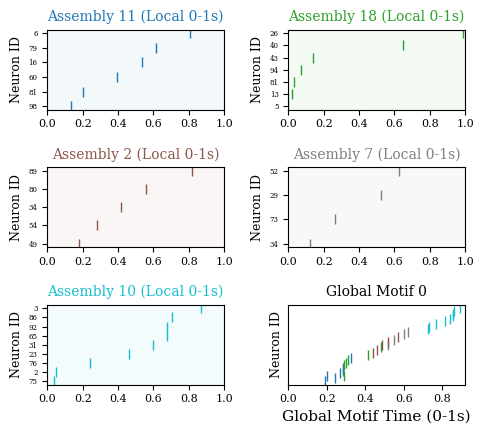

Done: (1, 1), (1, 1)


In [4]:
n_sig = [(0.02, 0.4), (1, 1)]
a_sig = [(0.02, 0.2), (1, 1)]
params["vol_param"] = (0.07, 0.9)
all_zmats = []
all_bmats = []
labels = []
noise_strN = ['lowN', 'highN']
noise_strA = ['lowA', 'highA']

for i, a in enumerate(a_sig):
    params['sig_a'] = a
    row_mats = []
    row_matsb = []
    row_labels = []
    for j, n in enumerate(n_sig):
        params['sigma_range'] = n
        offset_seqs, seqs_labels, spk_times, sequences, offset_true_templates, mu, sigma, volume, densities, cdfs, assembly_n_seq, assembly_n_spk, assembly_n_labels, subsequences_dict, subspike_times, raw_assembly_neurons_seq = simulate_sequences(**params, random_state=1, plot=False, return_subsequences=True)
# , assembly_n_seq, assembly_n_spk, assembly_n_labels, subsequences_dict, subspike_times, raw_assembly_neurons_seq
        data = {'bursts': subspike_times,
               'seqs': assembly_n_seq,
               'seqs_labels':assembly_n_labels,
               'true_templates': offset_true_templates}

        with open(f'overlap/overlap_subseqdata_vol_{params['vol_param']}_{params['vol_a']}_sig_{noise_strN[j]}_{noise_strA[i]}.pkl', 'wb') as f:
            pickle.dump(data, f)
            
        #_, _, _, bmat, zmat, corrmat = rs.allmot(offset_seqs, nrm) #seqs for individual assembly zmats | assembly_n_seq for assembly motif zmats
        #row_matsb.append(bmat)
        #row_mats.append(zmat)
        #row_labels.append(seqs_labels)
        
        print(f'Done: {a}, {n}')
    #all_zmats.append(row_mats)
    #all_bmats.append(row_matsb)
    #labels.append(row_labels)

In [16]:
file_name = f"raw_offset_subseqdata_vol_(0.07, 0.5)_(0.1, 0.3)_sig_lowN_lowA.pkl"
            
with open(file_name, 'rb') as f:
    opn = pickle.load(f)

In [18]:
opn['seqs']

[[77, 18, 31, 3, 21, 27, 7, 1, 37, 39],
 [77, 3, 1, 18, 7, 37],
 [18, 53, 82, 27, 31, 39, 1, 37, 7],
 [77, 53, 93, 18, 21, 39, 7, 1, 25, 37],
 [18, 77, 21, 1, 7, 37],
 [82, 53, 93, 21, 77, 18, 1, 15, 37, 7],
 [93, 77, 1, 18, 30, 7, 27, 0, 21, 37],
 [93, 18, 77, 3, 8, 7, 14, 21, 25, 37, 1],
 [93, 18, 3, 30, 7, 37, 1],
 [53, 77, 1, 18, 7, 37],
 [53, 77, 93, 18, 60, 1, 21, 7, 37],
 [93, 77, 3, 45, 18, 7],
 [30, 21, 34, 18, 1, 60, 0, 14, 37],
 [18, 77, 3, 30, 0, 1, 25, 21, 7, 37],
 [18, 93, 21, 82, 64, 53, 77, 3, 25],
 [31, 18, 53, 82, 27, 21, 1, 7, 0, 25, 12, 37],
 [53, 21, 18, 77, 0, 37, 1, 7],
 [93, 82, 39, 3, 77, 18, 0, 7, 25, 1, 37],
 [82, 93, 18, 77, 53, 31, 21, 27, 60, 25, 0, 7, 1],
 [18, 82, 93, 77, 3, 25, 1, 0, 37],
 [82, 18, 77, 31, 21, 27, 25, 37, 1],
 [82, 77, 21, 60, 7, 27, 1, 18, 37],
 [77, 31, 25, 18, 37],
 [53, 30, 77, 31, 93, 18, 3, 60, 25, 1, 37],
 [31, 77, 93, 53, 18, 27, 82, 1, 60, 21, 0, 37, 7],
 [18, 53, 93, 3, 1, 7, 21],
 [53, 77, 93, 3, 18, 27, 21, 1, 7, 25],
 [77, 

In [10]:
n_sig = [(0.02, 0.4), (1, 1)]
a_sig = [(0.02, 0.2), (1, 1)]

# Master lists that will hold the 2D grid structure
all_zmats = []
all_bmats = []
labels = []

noise_strN = ['lowN', 'highN']
noise_strA = ['lowA', 'highA']

for i, a in enumerate(a_sig):
    
    # Initialize lists to collect columns for the current row
    row_mats = []   # For zmats
    row_matsb = []  # For bmats
    row_labels = [] # For sequence labels
    
    for j in range(len(n_sig)):
        # 1. Properly construct the targeted file path
        file_name = f"overlap/overlap_subseqdata_vol_(0.07, 0.5)_(0.1, 0.3)_sig_{noise_strN[j]}_{noise_strA[i]}.pkl"
        
        # 2. Safely read dataset matrices
        with open(file_name, 'rb') as f:
            data = pickle.load(f)
        
        # 3. Calculate sequence correlation transformations 
        # Note: Extracting seqs_labels assuming it is stored in your file dictionary
        seqs_labels = data.get('seqs_labels', []) 
        _, _, _, bmat, zmat, corrmat = rs.allmot(data['seqs'], nrm)
        
        # 4. Append calculated results into the row lists
        row_matsb.append(bmat)
        row_mats.append(zmat)
        row_labels.append(seqs_labels)
        
    all_zmats.append(row_mats)
    all_bmats.append(row_matsb)
    labels.append(row_labels)

In [11]:
noise_strN = ['lowN', 'highN']
noise_strA = ['lowA', 'highA']

for i in range(len(a_sig)):
    for j in range(len(n_sig)):
        zmat = all_zmats[i][j]
        bmat = all_bmats[i][j]
        lbls = labels[i][j] 
        
        mat_dict = {
            'zmats': zmat,  
            'bmats': bmat,
            'labels': lbls
        }
        
        file_name = f"overlap/overlap_matrices_vol_(0.07, 0.5)_(0.1, 0.3)_sig_{noise_strN[j]}_{noise_strA[i]}.pkl"
        
        with open(file_name, 'wb') as f:
            pickle.dump(mat_dict, f)
            
        print(f"Successfully saved: {file_name}")

Successfully saved: overlap/overlap_matrices_vol_(0.07, 0.5)_(0.1, 0.3)_sig_lowN_lowA.pkl
Successfully saved: overlap/overlap_matrices_vol_(0.07, 0.5)_(0.1, 0.3)_sig_highN_lowA.pkl
Successfully saved: overlap/overlap_matrices_vol_(0.07, 0.5)_(0.1, 0.3)_sig_lowN_highA.pkl
Successfully saved: overlap/overlap_matrices_vol_(0.07, 0.5)_(0.1, 0.3)_sig_highN_highA.pkl


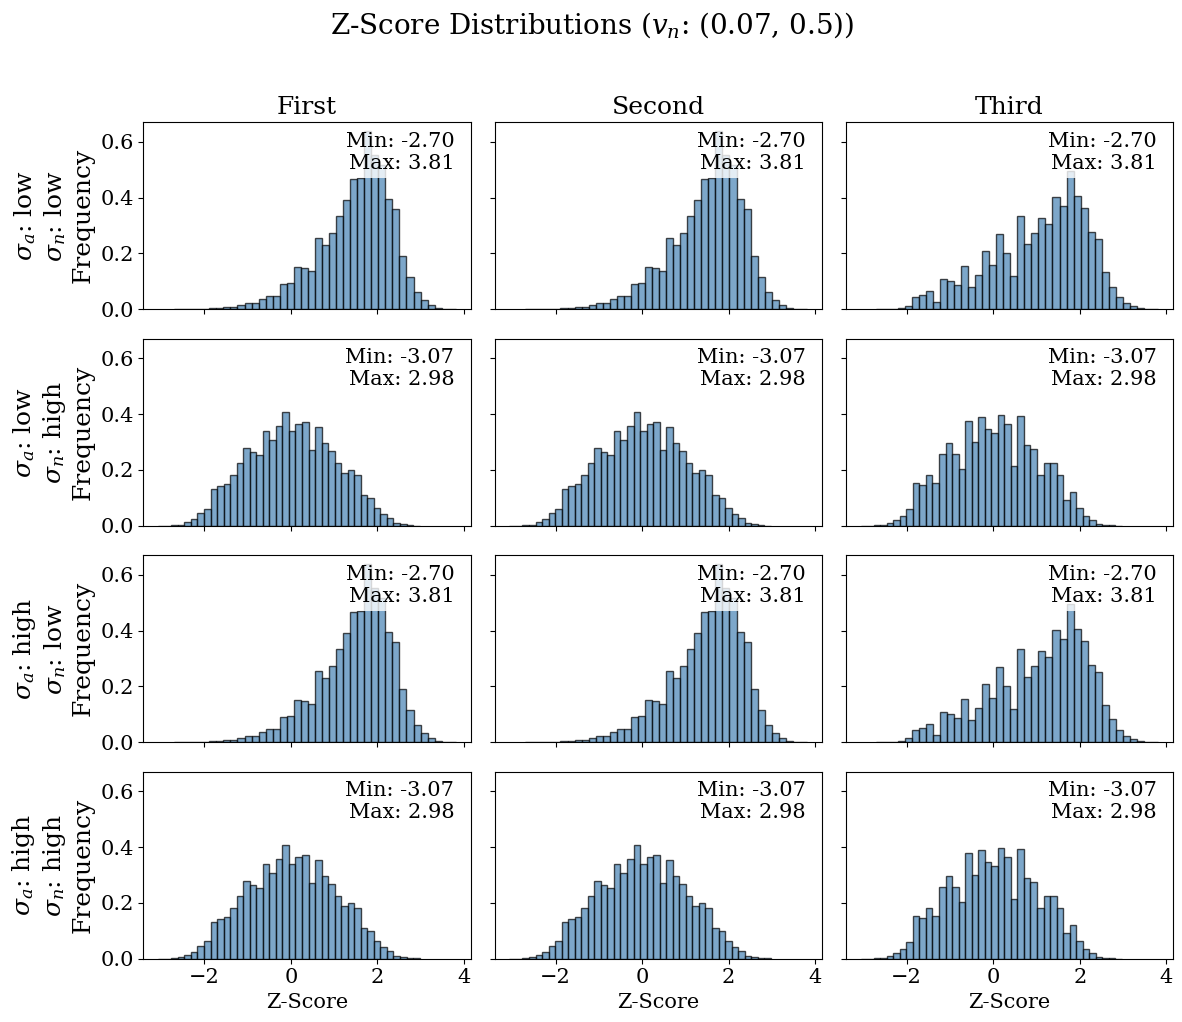

In [12]:
import itertools
import os

methods = ['append', 'offset', 'overlap']
method_labels = {
    'append': 'First',
    'offset': 'Second',
    'overlap': 'Third'
}
noise_strA = ['lowA', 'highA']
noise_strN = ['lowN', 'highN']

# Create the 4 combinations of noise: [(lowA, lowN), (lowA, highN), (highA, lowN), (highA, highN)]
sigma_combos = list(itertools.product(noise_strA, noise_strN)) 

vol_fixed = (0.1, 0.3)
vol_n = (0.07, 0.5)

# Create a 4x3 grid. sharex and sharey keep the axes aligned and clean.
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 10), sharex=True, sharey=True)

for col, method in enumerate(methods):
    for row, (sa, sn) in enumerate(sigma_combos):
        ax = axes[row, col]
        
        # NOTE: Adjust this string if your 'blabla' naming convention is slightly different!
        file_name = f"{method}/{method}_renorm_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl"
        
        if os.path.exists(file_name):
            with open(file_name, 'rb') as f:
                mat_dict = pickle.load(f)
                
            zmat = mat_dict['zmats']
            zmat_flat = np.array(zmat).flatten()
            
            ax.hist(zmat_flat, bins=40, color='steelblue', edgecolor='black', alpha=0.7, density=True)
            
            # Print the min and max directly onto the plot so your supervisor can see them easily
            z_min, z_max = np.nanmin(zmat), np.nanmax(zmat)
            ax.text(0.95, 0.95, f"Min: {z_min:.2f}\nMax: {z_max:.2f}", 
                    transform=ax.transAxes, ha='right', va='top', fontsize=15,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            
        else:
            ax.text(0.5, 0.5, "Data Missing\nor File Not Found", ha='center', va='center', color='red')

        # --- Formatting and Labels ---
        # Set column titles (Top Row)
        if row == 0:
            display_name = method_labels.get(method, method.capitalize())
            ax.set_title(f"{display_name}", fontsize=18)
            
        # Set row labels (Left Column)
        if col == 0:
            # 1. Clean the strings (turns 'lowA' into 'low')
            sa_clean = sa.replace('A', '')
            sn_clean = sn.replace('N', '')
            
            # 2. Use Matplotlib's LaTeX formatting for the greek letters
            label_text = f"$\\sigma_a$: {sa_clean}\n$\\sigma_n$: {sn_clean}\nFrequency"
            
            ax.set_ylabel(label_text, fontsize=18)
            
        # Set x-axis labels (Bottom Row)
        if row == 3:
            ax.set_xlabel("Z-Score", fontsize=15)
        ax.tick_params(axis="both", labelsize=15)

# Global title
fig.suptitle(f"Z-Score Distributions ($v_n$: {vol_n})", fontsize=20, y=1.02)

plt.tight_layout()
#plt.savefig("zscore_dist_(0.07, 0.5).jpg", dpi=300)
#plt.savefig("zscore_dist_(0.07, 0.5).pdf", dpi=300)
plt.show()

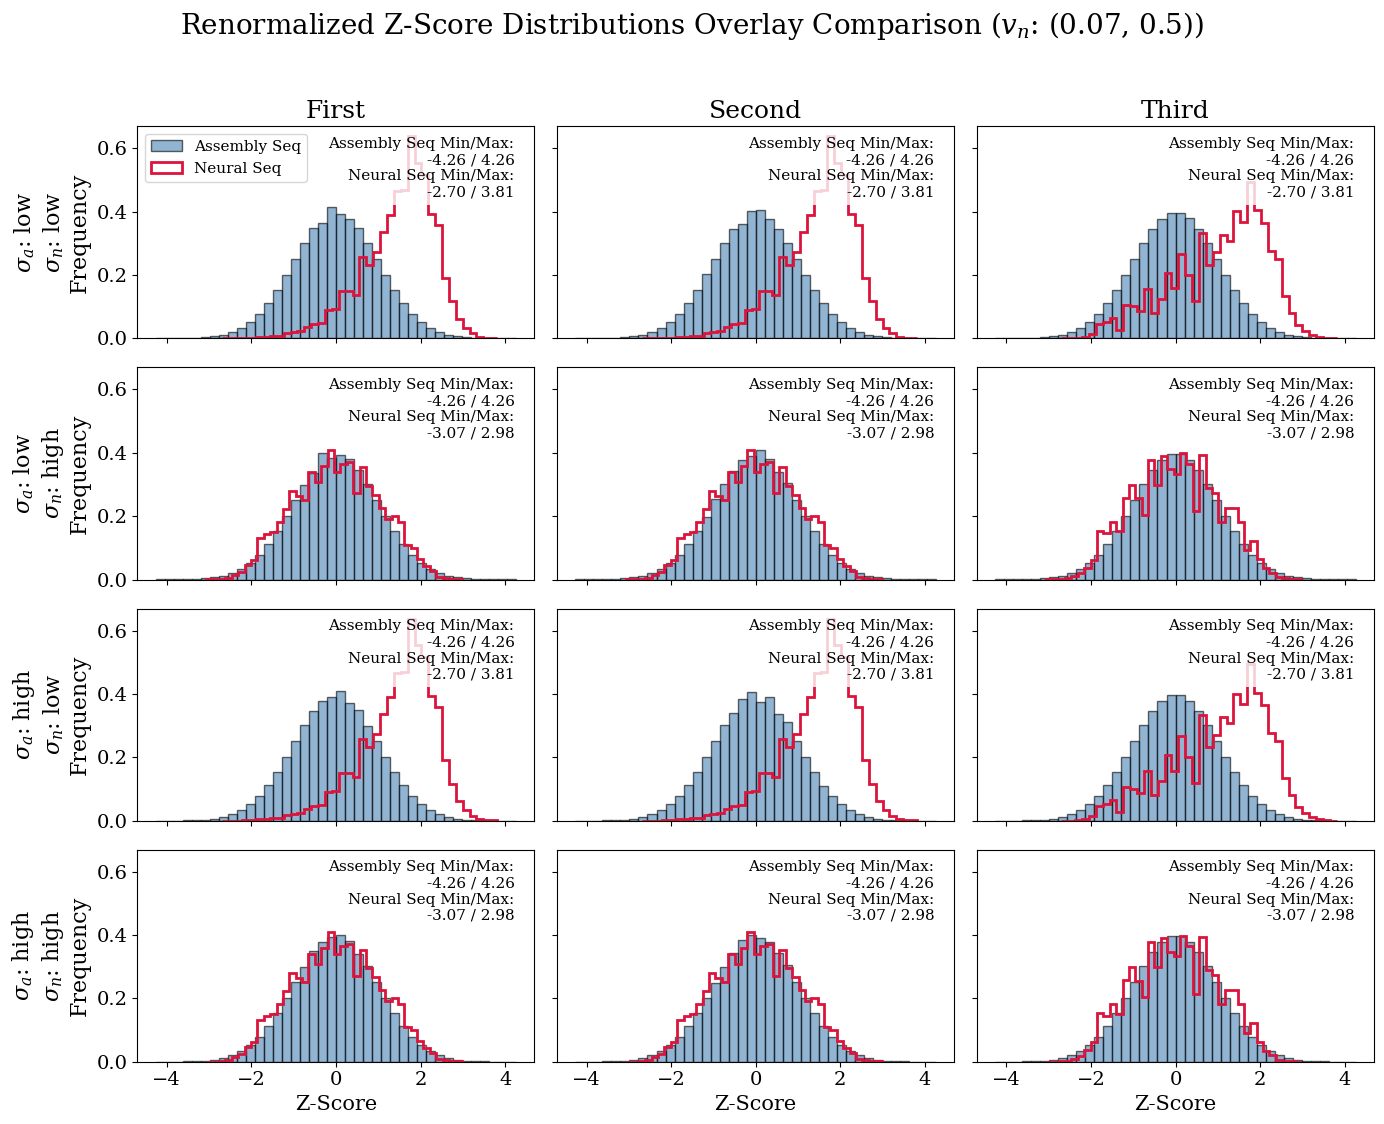

In [25]:
import os
import pickle
import itertools
import numpy as np
import matplotlib.pyplot as plt

methods = ['append', 'offset', 'overlap']
method_labels = {
    'append': 'First',
    'offset': 'Second',
    'overlap': 'Third'
}
noise_strA = ['lowA', 'highA']
noise_strN = ['lowN', 'highN']

# Create the 4 combinations of noise
sigma_combos = list(itertools.product(noise_strA, noise_strN)) 

vol_fixed = (0.1, 0.3)
vol_n = (0.07, 0.5)

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(14, 11), sharex=True, sharey=True)

for col, method in enumerate(methods):
    for row, (sa, sn) in enumerate(sigma_combos):
        ax = axes[row, col]
        
        reg_file = f"{method}/{method}_renorm_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl"

        raw_folder = 'offset' if method == 'append' else method
        raw_file = f"{raw_folder}/raw_offset_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl" if method == 'append' else f"{method}/raw_{method}_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl"

        # Track text stats to show on the plot
        stats_text = ""
        
        if os.path.exists(reg_file):
            with open(reg_file, 'rb') as f:
                reg_dict = pickle.load(f)
            reg_z = np.array(reg_dict['zmats_renormalized']).flatten()
            
            ax.hist(reg_z, bins=40, color='steelblue', edgecolor='black', alpha=0.6, 
                    density=True, label='Assembly Seq')
            stats_text += f"Assembly Seq Min/Max:\n{np.nanmin(reg_z):.2f} / {np.nanmax(reg_z):.2f}\n"
            
        if os.path.exists(raw_file):
            with open(raw_file, 'rb') as f:
                raw_dict = pickle.load(f)
            raw_z = np.array(raw_dict['zmats']).flatten()
            
            # Using histtype='step' with a thicker line style prevents visual clashing
            ax.hist(raw_z, bins=40, color='crimson', linewidth=2, histtype='step', 
                    density=True, label='Neural Seq')
            stats_text += f"Neural Seq Min/Max:\n{np.nanmin(raw_z):.2f} / {np.nanmax(raw_z):.2f}"

        if os.path.exists(reg_file) or os.path.exists(raw_file):
            ax.text(0.95, 0.95, stats_text.strip(), 
                    transform=ax.transAxes, ha='right', va='top', fontsize=11,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            # Place a dynamic legend on the top-left chart corner to explain colors cleanly
            if row == 0 and col == 0:
                ax.legend(loc='upper left', fontsize=11)
        else:
            ax.text(0.5, 0.5, "Both Datasets\nMissing", ha='center', va='center', color='red')

        # Set column titles (Top Row)
        if row == 0:
            display_name = method_labels.get(method, method.capitalize())
            ax.set_title(f"{display_name}", fontsize=18)
            
        # Set row labels (Left Column)
        if col == 0:
            sa_clean = sa.replace('A', '')
            sn_clean = sn.replace('N', '')
            label_text = f"$\\sigma_a$: {sa_clean}\n$\\sigma_n$: {sn_clean}\nFrequency"
            ax.set_ylabel(label_text, fontsize=16)
            
        # Set x-axis labels (Bottom Row)
        if row == 3:
            ax.set_xlabel("Z-Score", fontsize=15)
        ax.tick_params(axis="both", labelsize=14)

fig.suptitle(f"Renormalized Z-Score Distributions Overlay Comparison ($v_n$: {vol_n})", fontsize=20, y=1.02)

plt.tight_layout()
plt.savefig("zscore_overlay_comparison_renorm.jpg", dpi=300, bbox_inches='tight')
plt.savefig("zscore_overlay_comparison_renorm.pdf", dpi=300, bbox_inches='tight')
plt.show()

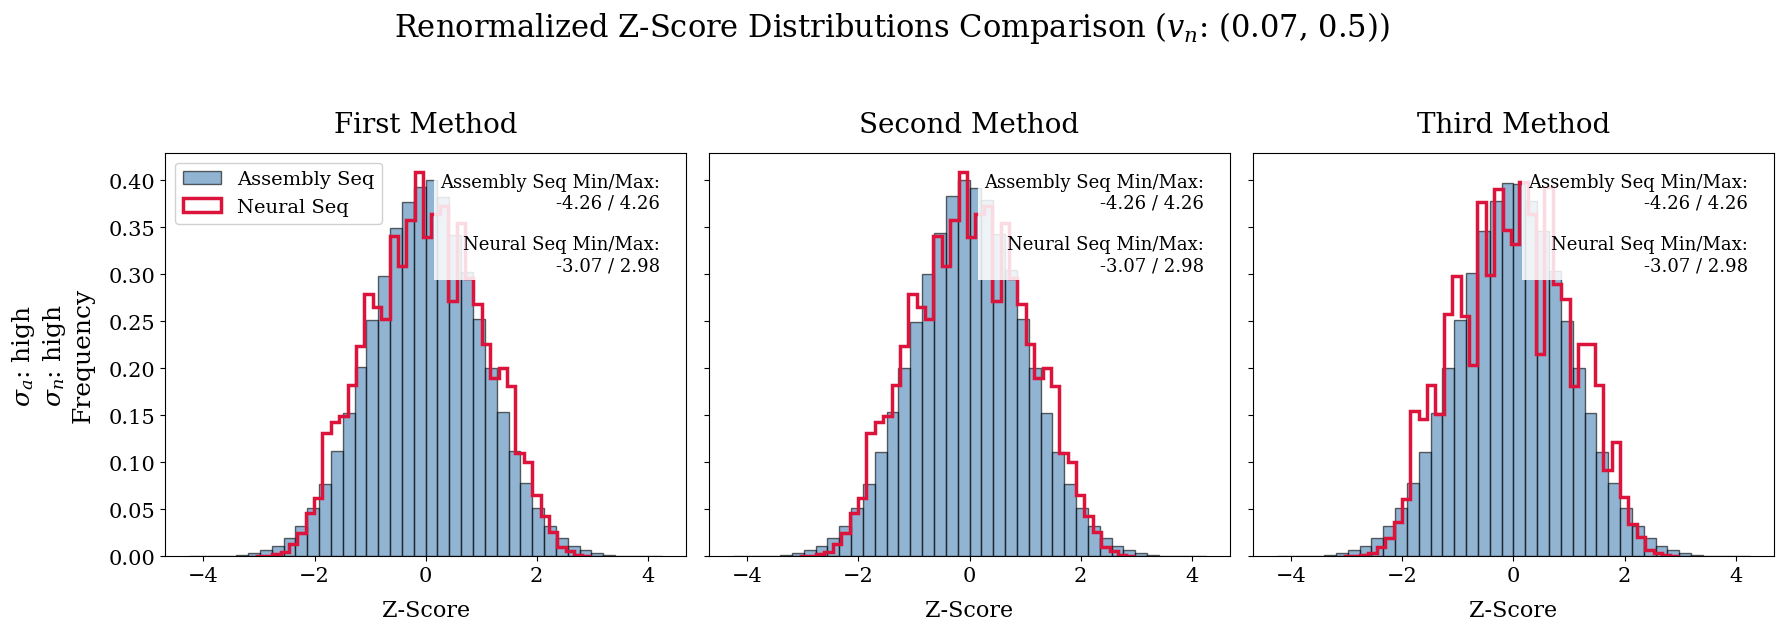

In [24]:
import os
import pickle
import itertools
import numpy as np
import matplotlib.pyplot as plt
methods = ['append', 'offset', 'overlap']
method_labels = {
    'append': 'First',
    'offset': 'Second',
    'overlap': 'Third'
}

# Fix parameters strictly to the high-high noise regime
sa = 'highA'
sn = 'highN'
vol_fixed = (0.1, 0.3)
vol_n = (0.07, 0.5)

# Create a 1x3 grid layout with extra space for large, readable fonts
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

for col, method in enumerate(methods):
    ax = axes[col]
    
    reg_file = f"{method}/{method}_renorm_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl"
    
    # Raw File Path (Accounting for the append exception pointing to offset folder)
    raw_folder = 'offset' if method == 'append' else method
    if method == 'append':
        raw_file = f"{raw_folder}/raw_offset_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl"
    else:
        raw_file = f"{method}/raw_{method}_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl"

    stats_text = ""
    
    # --- 2. Plot Regular Dataset (Background Solid Hist) ---
    if os.path.exists(reg_file):
        with open(reg_file, 'rb') as f:
            reg_dict = pickle.load(f)
        reg_z = np.array(reg_dict['zmats_renormalized']).flatten()
        
        ax.hist(reg_z, bins=40, color='steelblue', edgecolor='black', alpha=0.6, 
                density=True, label='Assembly Seq')
        stats_text += f"Assembly Seq Min/Max:\n{np.nanmin(reg_z):.2f} / {np.nanmax(reg_z):.2f}\n\n"
        
    # --- 3. Plot Raw Dataset (Foreground Step Hist for Comparison) ---
    if os.path.exists(raw_file):
        with open(raw_file, 'rb') as f:
            raw_dict = pickle.load(f)
        raw_z = np.array(raw_dict['zmats']).flatten()
        
        ax.hist(raw_z, bins=40, color='crimson', linewidth=2.5, histtype='step', 
                density=True, label='Neural Seq')
        stats_text += f"Neural Seq Min/Max:\n{np.nanmin(raw_z):.2f} / {np.nanmax(raw_z):.2f}"

    # --- 4. Large Text Annotations and Text Boxes ---
    if os.path.exists(reg_file) or os.path.exists(raw_file):
        ax.text(0.95, 0.95, stats_text.strip(), 
                transform=ax.transAxes, ha='right', va='top', fontsize=13,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
        
        # Place legend on the first plot using a clear, larger layout
        if col == 0:
            ax.legend(loc='upper left', fontsize=14, framealpha=0.9)
    else:
        ax.text(0.5, 0.5, "Both Datasets\nMissing", ha='center', va='center', 
                color='red', fontsize=16, fontweight='bold')

    # --- Formatting and Labels ---
    # Large Method Subplot Title
    display_name = method_labels.get(method, method.capitalize())
    ax.set_title(f"{display_name} Method", fontsize=20, pad=15)
    
    # Large X-Axis Label for all subplots
    ax.set_xlabel("Z-Score", fontsize=16, labelpad=10)
    
    # Leftmost plot gets the dynamic noise parameter row descriptors
    if col == 0:
        sa_clean = sa.replace('A', '')
        sn_clean = sn.replace('N', '')
        label_text = f"$\\sigma_a$: {sa_clean}\n$\\sigma_n$: {sn_clean}\nFrequency"
        ax.set_ylabel(label_text, fontsize=18, labelpad=10)
        
    ax.tick_params(axis="both", labelsize=15)

# Main Title summarizing parameters
fig.suptitle(f"Renormalized Z-Score Distributions Comparison ($v_n$: {vol_n})", fontsize=22, y=1.05)

plt.tight_layout()
plt.savefig("zscore_(1,1)_comparison_renorm.jpg", dpi=300, bbox_inches='tight')
plt.savefig("zscore_(1,1)_comparison_renorm.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
from scipy import stats
from scipy.stats import rankdata # Import this specifically!
import numpy as np
import itertools
import os
import pickle

methods = ['append', 'offset', 'overlap']
noise_strA = ['lowA', 'highA']
noise_strN = ['lowN', 'highN']
vol_fixed = (0.1, 0.3)
vol_n = (0.07, 0.5)

sigma_combos = list(itertools.product(noise_strA, noise_strN)) 

for col, method in enumerate(methods):
    for row, (sa, sn) in enumerate(sigma_combos):
        
        reg_file = f"{method}/{method}_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl"
        
        if os.path.exists(reg_file):
            with open(reg_file, 'rb') as f:
                reg_dict = pickle.load(f)
                
            # 1. Flatten and mask
            zmat_raw = np.array(reg_dict['zmats'])
            zmat_flat = zmat_raw.flatten()
            valid_mask = ~np.isnan(zmat_flat)
            
            valid_scores = zmat_flat[valid_mask]
            
            if len(valid_scores) > 0:
                # 2. FAST VECTORIZED PERCENTILES (Takes fractions of a second)
                # rankdata returns the rank (1 to N) of each score. 
                # Dividing by N gives you the exact 0.0 to 1.0 probability.
                ranks = rankdata(valid_scores, method='average')
                percentiles = ranks / len(valid_scores)
                
                # 3. Clip strictly to prevent Infinity errors
                percentiles = np.clip(percentiles, 0.00001, 0.99999)
                
                # 4. Map back to Standard Normal
                renormalized_scores = stats.norm.ppf(percentiles)
                
                # 5. Put the renormalized scores back into the flat array
                zmat_flat_renorm = np.full(zmat_flat.shape, np.nan)
                zmat_flat_renorm[valid_mask] = renormalized_scores
                
                # OPTIONAL BUT RECOMMENDED: Save the new matrices back into the dictionary
                
                save_file = f"{method}/{method}_renorm_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl"
                reg_dict['zmats_renormalized'] = zmat_flat_renorm.reshape(zmat_raw.shape)
                with open(save_file, 'wb') as f:
                    pickle.dump(reg_dict, f)

        print(f'Done: {method} {sa}, {sn}')

Done: append lowA, lowN
Done: append lowA, highN
Done: append highA, lowN
Done: append highA, highN
Done: offset lowA, lowN
Done: offset lowA, highN
Done: offset highA, lowN
Done: offset highA, highN
Done: overlap lowA, lowN
Done: overlap lowA, highN
Done: overlap highA, lowN
Done: overlap highA, highN


In [18]:
within_scores = []
within_vars = []
for i in range(len(a_sig)):
    for j in range(len(n_sig)):
        zmat = all_zmats[i][j]
        bmat = all_bmats[i][j]
        lbls = labels[i][j] 
        
        w_score, w_var = add_within_clust_score(lbls, zmat, bmat)
        within_scores.append(w_score)
        within_vars.append(w_var)

# Flatten the nested Z-matrices into a simple list of 4
flat_zmats = [m for row in all_zmats for m in row]
flat_labels = [m for row in labels for m in row]

plot_titles = []
for a in a_sig:
    for n in n_sig:
        plot_titles.append(f"Asmb Noise: {a}\nNeur Noise: {n}")


In [29]:
import os
import pickle

# Ensure these are defined for the specific set you are analyzing
method = 'append' 

within_scores = []
within_vars = []
flat_zmats = []
flat_labels = []
plot_titles = []

methods = ['append', 'offset', 'overlap']
a_sig = ['lowA', 'highA']
n_sig = ['lowN', 'highN']
vol_fixed = (0.1, 0.3)
vol_n = (0.07, 0.5) 

for i in range(len(a_sig)):
    for j in range(len(n_sig)):
        sa = a_sig[i]
        sn = n_sig[j]
        
        # 1. Target the NEW renormalized file you created
        file_name = f"{method}/{method}_renorm_matrices_vol_{vol_n}_{vol_fixed}_sig_{sn}_{sa}.pkl"
        
        if os.path.exists(file_name):
            with open(file_name, 'rb') as f:
                reg_dict = pickle.load(f)
                
            # 2. Extract the data directly from the dictionary
            zmat = reg_dict['zmats_renormalized']  # <-- Pulling the normalized data!
            bmat = reg_dict['bmats']               # Pulling the standard bmats
            lbls = reg_dict['labels']              # Pulling the standard labels
            
            # 3. Calculate your scores using the perfectly scaled Z-matrix
            w_score, w_var = add_within_clust_score(lbls, zmat, bmat)
            within_scores.append(w_score)
            within_vars.append(w_var)
            
            # 4. Append directly to flat lists for your plotting later
            flat_zmats.append(zmat)
            flat_labels.append(lbls)
            
        else:
            print(f"File missing: {file_name}")
            
        # Add the titles for your subplots
        plot_titles.append(f"Asmb Noise: {sa}\nNeur Noise: {sn}")


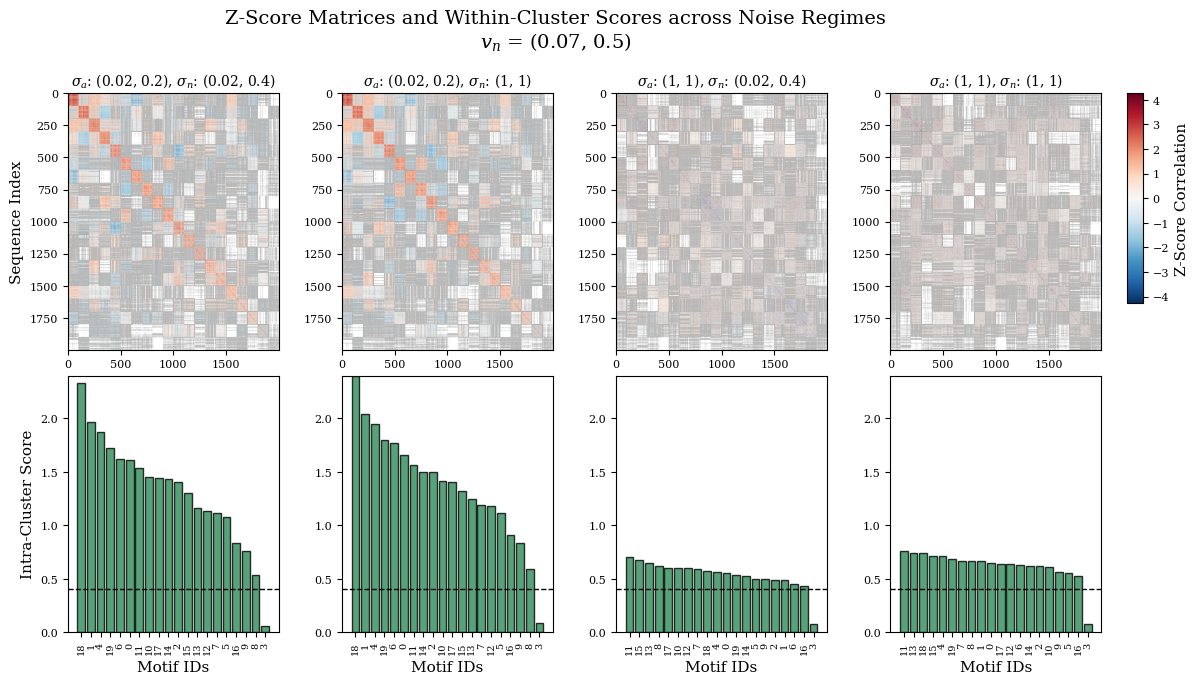

In [33]:
import matplotlib.pyplot as plt
import numpy as np


a_sig = ['(0.02, 0.2)', '(1, 1)']
n_sig = ['(0.02, 0.4)', '(1, 1)']

def plot_mats_and_bars_sorted(zmats, scores, labels_list, a_sig, n_sig):
    """
    zmats: flattened list of 4 Z-matrices
    scores: flattened list of 4 arrays (mean scores per motif)
    labels_list: flattened list of 4 label arrays (sequence-wise ground truth IDs)
    """
    n_cols = 4
    fig, axes = plt.subplots(2, n_cols, figsize = (13,7))

    # 1. Global Heatmap Scaling
    global_min = np.nanmin([np.nanmin(m) for m in zmats])
    global_max = np.nanmax([np.nanmax(m) for m in zmats])
    abs_max = max(abs(global_min), abs(global_max))
    global_max_score = np.nanmax([np.nanmax(s) for s in scores])

    for k in range(n_cols):
        i_a = k // 2
        j_n = k % 2
        
        # Current data for this parameter set
        zmat = np.array(zmats[k])
        motif_scores = np.array(scores[k])
        lbls = np.array(labels_list[k])
        unique_motifs = np.unique(lbls) # Labels returned by np.unique are sorted ascending

        # Sort the motif IDs based on their corresponding scores (Descending)
        sorted_indices = np.argsort(motif_scores)[::-1]
        sorted_motif_ids = unique_motifs[sorted_indices]
        sorted_motif_scores = motif_scores[sorted_indices]

        # Reorder the sequence-wise Z-matrix
        # We find all indices in 'lbls' for each motif in our new sorted order
        new_seq_order = []
        for m_id in sorted_motif_ids:
            # Grab original indices where sequences belong to this motif
            idx = np.where(lbls == m_id)[0]
            new_seq_order.extend(idx)
        
        new_seq_order = np.array(new_seq_order)
        # Apply the new ordering to both rows and columns of the matrix
        sorted_zmat = zmat[np.ix_(new_seq_order, new_seq_order)]

        # --- TOP ROW: Z-Matrices (Sorted) ---
        ax_top = axes[0, k]
        im = ax_top.imshow(sorted_zmat, aspect='auto', cmap='RdBu_r', 
                           vmin=-abs_max, vmax=abs_max)
        
        ax_top.set_title(fr"$\sigma_a$: {a_sig[i_a]}, $\sigma_n$: {n_sig[j_n]}", fontsize=10)
        if k == 0: ax_top.set_ylabel("Sequence Index")

        # --- BOTTOM ROW: Bar Plot (Sorted) ---
        ax_bot = axes[1, k]
        
        # Convert IDs to strings for categorical x-axis labels to maintain order
        x_labels = [str(int(m)) for m in sorted_motif_ids]
        ax_bot.bar(x_labels, sorted_motif_scores, color='seagreen', alpha=0.8, edgecolor='black')
        
        ax_bot.set_ylim(0, global_max_score)
        ax_bot.tick_params(axis='x', labelsize=7, rotation=90)
        
        if k == 0: 
            ax_bot.set_ylabel("Intra-Cluster Score")
        ax_bot.set_xlabel("Motif IDs")
        ax_bot.axhline(0.4, color='black', linestyle='dashed')

    # 3. Add Shared Colorbar
    cbar_ax = fig.add_axes([0.94, 0.58, 0.012, 0.3]) 
    fig.colorbar(im, cax=cbar_ax, label='Z-Score Correlation')

    fig.suptitle(f'Z-Score Matrices and Within-Cluster Scores across Noise Regimes\n$v_n$ = {vol_n}', 
             fontsize=14, y=1)
    plt.subplots_adjust(wspace=0.3, hspace=0.1, right=0.92)
    
    #plt.savefig(f'woffset_raw_zscore_intracluster_{params["vol_param"]}.jpg', dpi=300)
    #plt.savefig(f'woffset_raw_zscore_intracluster_{params["vol_param"]}.pdf', dpi=300)
    plt.show()

plot_mats_and_bars_sorted(flat_zmats, within_scores, flat_labels, a_sig, n_sig)

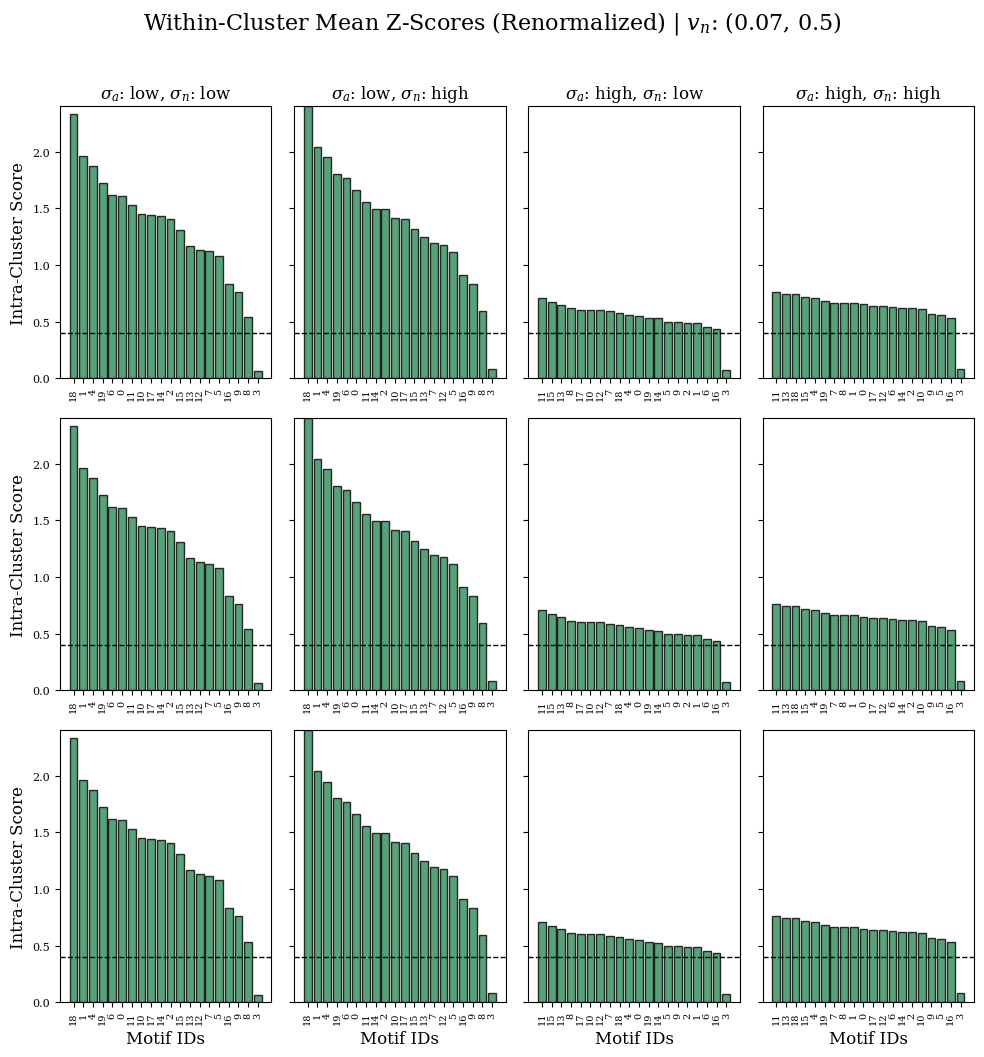

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import itertools

# 1. Configuration
methods = ['append', 'offset', 'overlap']
noise_strA = ['lowA', 'highA']
noise_strN = ['lowN', 'highN']
sigma_combos = list(itertools.product(noise_strA, noise_strN))

vol_fixed = (0.1, 0.3)
vol_n = (0.07, 0.5)

# 2. Setup the 3x4 Grid
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 11), sharey=True)

for row, method in enumerate(methods):
    global_min = np.nanmin([np.nanmin(m) for m in flat_zmats])
    global_max = np.nanmax([np.nanmax(m) for m in flat_zmats])
    abs_max = max(abs(global_min), abs(global_max))
    global_max_score = np.nanmax([np.nanmax(s) for s in within_scores])
    
    for col, (sa, sn) in enumerate(sigma_combos):
        ax = axes[row, col]
        
        zmat = np.array(flat_zmats[col])
        motif_scores = np.array(within_scores[col])
        lbls = np.array(flat_labels[col])
        unique_motifs = np.unique(lbls) # Labels returned by np.unique are sorted ascending
        
        # Sort the motif IDs based on their corresponding scores (Descending)
        sorted_indices = np.argsort(motif_scores)[::-1]
        sorted_motif_ids = unique_motifs[sorted_indices]
        sorted_motif_scores = motif_scores[sorted_indices]

        # Reorder the sequence-wise Z-matrix
        # We find all indices in 'lbls' for each motif in our new sorted order
        new_seq_order = []
        for m_id in sorted_motif_ids:
            # Grab original indices where sequences belong to this motif
            idx = np.where(lbls == m_id)[0]
            new_seq_order.extend(idx)
        
        new_seq_order = np.array(new_seq_order)
        # Apply the new ordering to both rows and columns of the matrix
        sorted_zmat = zmat[np.ix_(new_seq_order, new_seq_order)]
        
        # Convert IDs to strings for categorical x-axis labels to maintain order
        x_labels = [str(int(m)) for m in sorted_motif_ids]
        ax.bar(x_labels, sorted_motif_scores, color='seagreen', alpha=0.8, edgecolor='black')
        
        ax.set_ylim(0, global_max_score)
        ax.tick_params(axis='x', labelsize=7, rotation=90)
        if col == 0:
            ax.set_ylabel("Intra-Cluster Score", fontsize=12)
        if row == 0:
            if 'low' in sa:
                sa = 'low'
            else:
                sa = 'high'
            if 'low' in sn:
                sn = 'low'
            else:
                sn = 'high'
            ax.set_title(fr"$\sigma_a$: {sa}, $\sigma_n$: {sn}", fontsize=12)
        if row == 2:
            ax.set_xlabel("Motif IDs", fontsize=12)
        ax.axhline(0.4, color='black', linestyle='dashed')

# 3. Global Formatting
fig.suptitle(f"Within-Cluster Mean Z-Scores (Renormalized) | $v_n$: {vol_n}", fontsize=16, y=0.96)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('zscores_renorm_subseq.jpg', dpi = 300)
plt.savefig('zscores_renorm_subseq.pdf', dpi = 300)
plt.show()

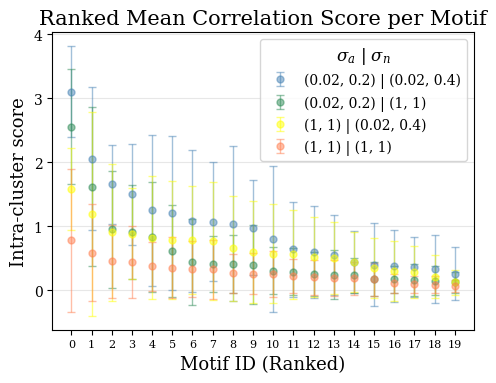

In [9]:
# Plot
fig, ax = plt.subplots(figsize=(5, 4))
colors = ['steelblue', 'seagreen', 'yellow', 'coral']
jitter_strength = 0.03
for i in range(4):
    x_positions = range(len(ranked_results[i]['motifs']))
    jitter_orig = np.random.normal(0, jitter_strength)
            
    ax.errorbar(x_positions, vol_ranked_data[i]['scores'], yerr=vol_ranked_data[i]['vars'], 
                            fmt='o', color=colors[i], 
                            capsize=3, markersize=5, elinewidth=1, alpha=0.5, label=vol_ranked_data[i]['params'])
            

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_positions, fontsize=8)
    ax.tick_params(axis='y', labelsize=10)
        
    ax.set_xlabel('Motif ID (Ranked)', fontsize=13)
    ax.set_ylabel('Intra-cluster score', fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(title=fr'$\sigma_a$ | $\sigma_n$')
    
plt.title(f'Ranked Mean Correlation Score per Motif', fontsize=15)
plt.tight_layout()
#plt.savefig(f'offfset_corrscore_comp_{params['vol_param']}.jpg', dpi=300)
#plt.savefig(f'offfset_corrscore_comp_{params['vol_param']}.pdf', dpi=300)
plt.show()


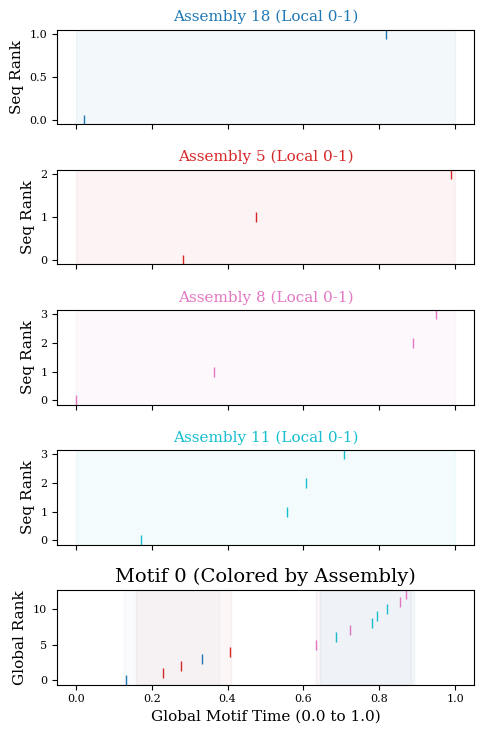

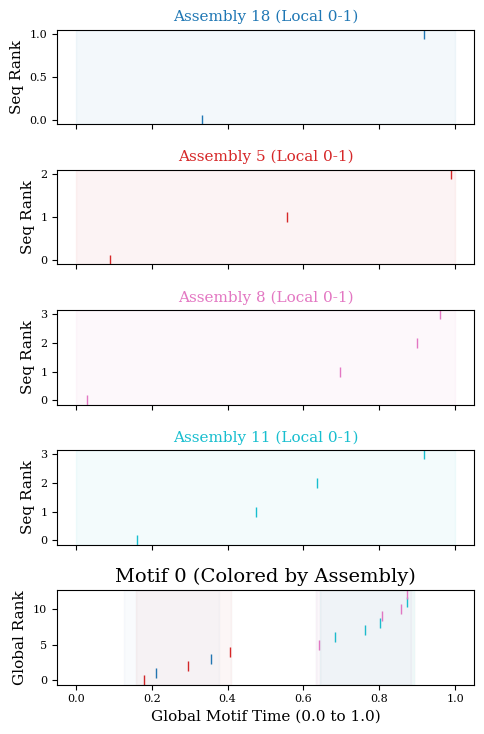

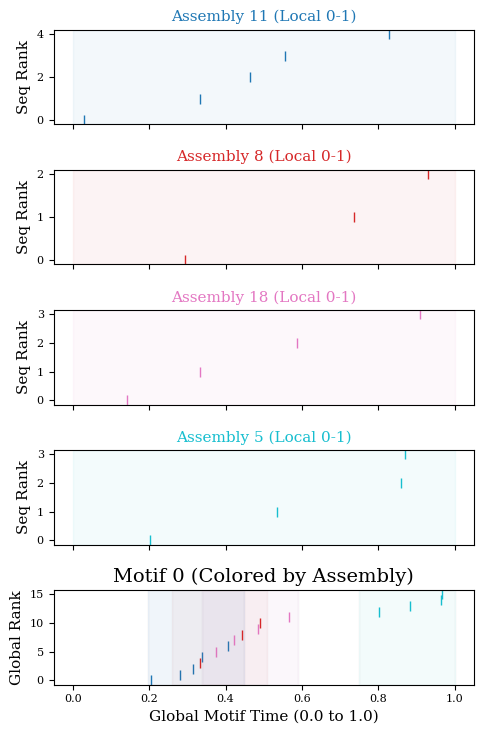

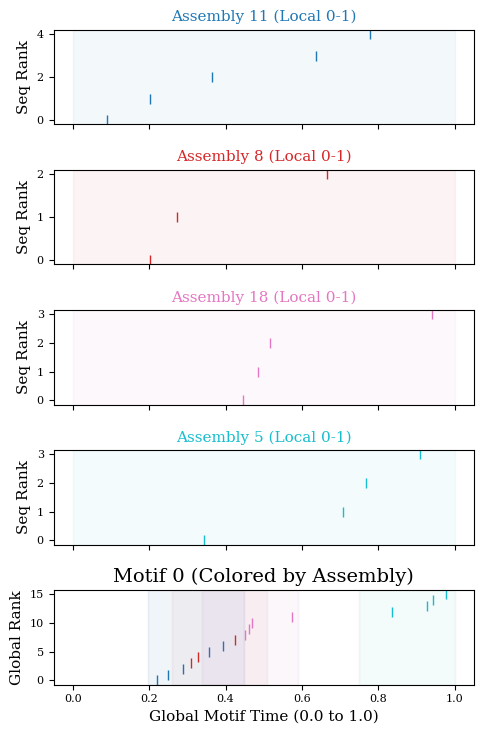

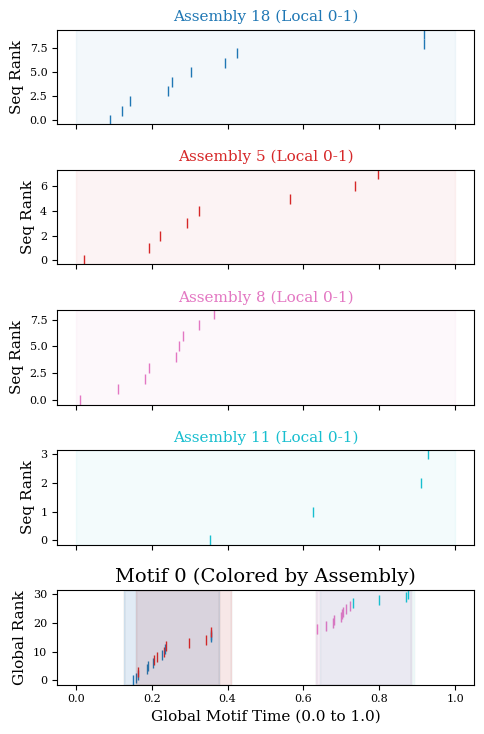

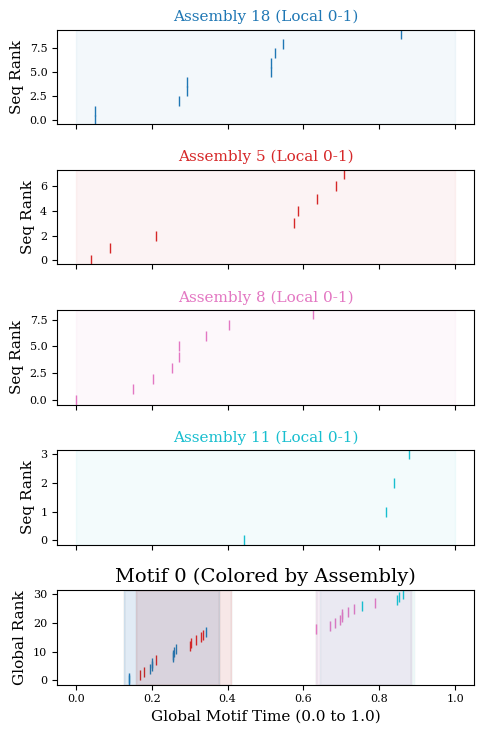

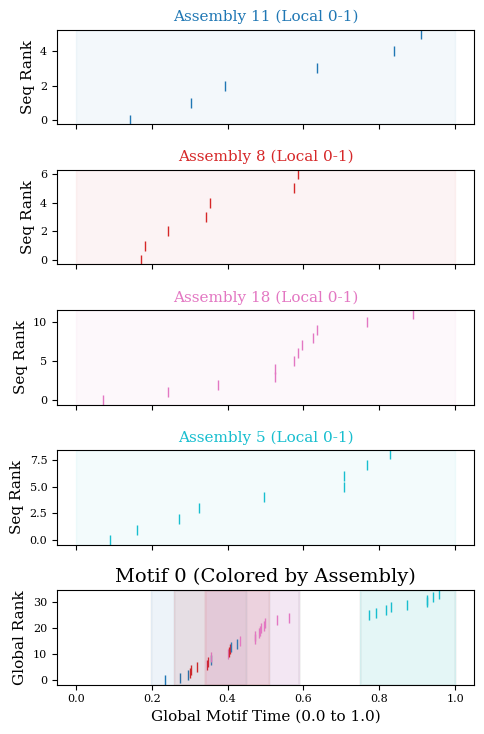

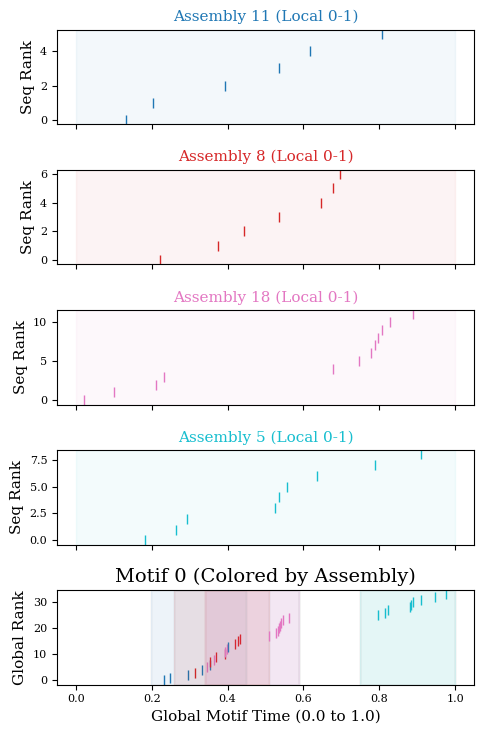

In [4]:
# Define your parameter ranges
volumes = [(0.03, 0.9), (0.07, 0.9)] # Example volume list
a_sigs = [(0.02, 0.2), (1, 1)]                 # Example sig_a
n_sigs = [(0.02, 0.4), (1, 1)]                 # Example sig_n

all_results = {}

for v_param in volumes:
    params['vol_param'] = v_param
    vol_ranked_data = []
    
    for a in a_sigs:
        params['sig_a'] = a
        for n in n_sigs:
            params['sigma_range'] = n
            
            _, _, _, _, _, _, _, _, _, _, assembly_n_seq, _, assembly_n_labels, _, _, _  = simulate_sequences(**params, random_state=1, plot=False, return_subsequences=True)
            seqs = assembly_n_seq
            lbls_orig = assembly_n_labels
            
            kept_idx = [idx for idx, s in enumerate(seqs) if len(s) >= 2]
            filtered_seqs = [seqs[idx] for idx in kept_idx]
            filtered_labels = np.array(lbls_orig)[kept_idx]
            
            _, _, _, bmat, zmat, _ = rs.allmot(filtered_seqs, nrm)
            
            w_scores, w_vars = add_within_clust_score(filtered_labels, zmat, bmat)
            
            unique_motifs = np.unique(filtered_labels)
            sorted_indices = np.argsort(w_scores)[::-1]
            
            vol_ranked_data.append({
                'scores': w_scores[sorted_indices],
                'vars': w_vars[sorted_indices],
                'motifs': unique_motifs[sorted_indices],
                'zmat': zmat,
                'labels': filtered_labels,
                'params': f'{a} | {n}'
            })
            
    # Store all 4 noise results for this specific volume
    all_results[str(v_param)] = vol_ranked_data

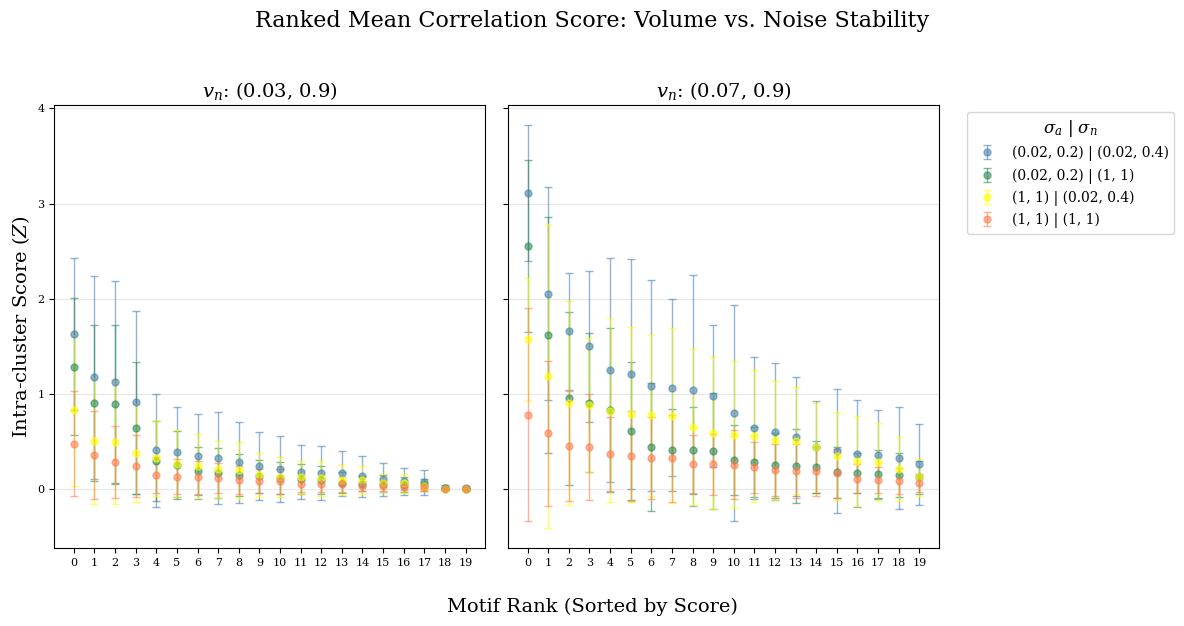

In [14]:
n_vols = len(volumes)
fig, axes = plt.subplots( 1, n_vols, figsize=(6 * n_vols,6), sharex=True, sharey = True)
if n_vols == 1: axes = [axes]
    
colors = ['steelblue', 'seagreen', 'yellow', 'coral']

for idx, v_param in enumerate(volumes):
    ax = axes[idx]
    v_key = str(v_param)
    ranked_results = all_results[v_key]
    
    for i in range(4): 
        x_positions = np.arange(len(ranked_results[i]['scores']))
        
        ax.errorbar(x_positions, ranked_results[i]['scores'], 
                    yerr=ranked_results[i]['vars'], 
                    fmt='o', color=colors[i], capsize=3, 
                    markersize=5, elinewidth=1, alpha=0.6, 
                    label=ranked_results[i]['params'])

    ax.set_title(fr'$v_n$: {v_param}', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_positions, fontsize=8)

fig.supxlabel('Motif Rank (Sorted by Score)', fontsize=14)

axes[0].set_ylabel('Intra-cluster Score ($Z$)', fontsize=14)
axes[1].legend(title=fr'$\sigma_a$ | $\sigma_n$', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Ranked Mean Correlation Score: Volume vs. Noise Stability', fontsize=16, y=1.02)
plt.tight_layout()

# Save using the specific volume parameters in the filename
vol_filename = "_".join([str(v).replace(" ","") for v in volumes])
#plt.savefig(f'volume_comparison_ranked_scores.png', dpi=300, bbox_inches='tight')
plt.show()

<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1072225/4085357893.py:48: SyntaxWarning: invalid escape sequence '\s'
  ax_top.set_title(f"$\sigma_a | \sigma_n$: {data['params']}", fontsize=12)


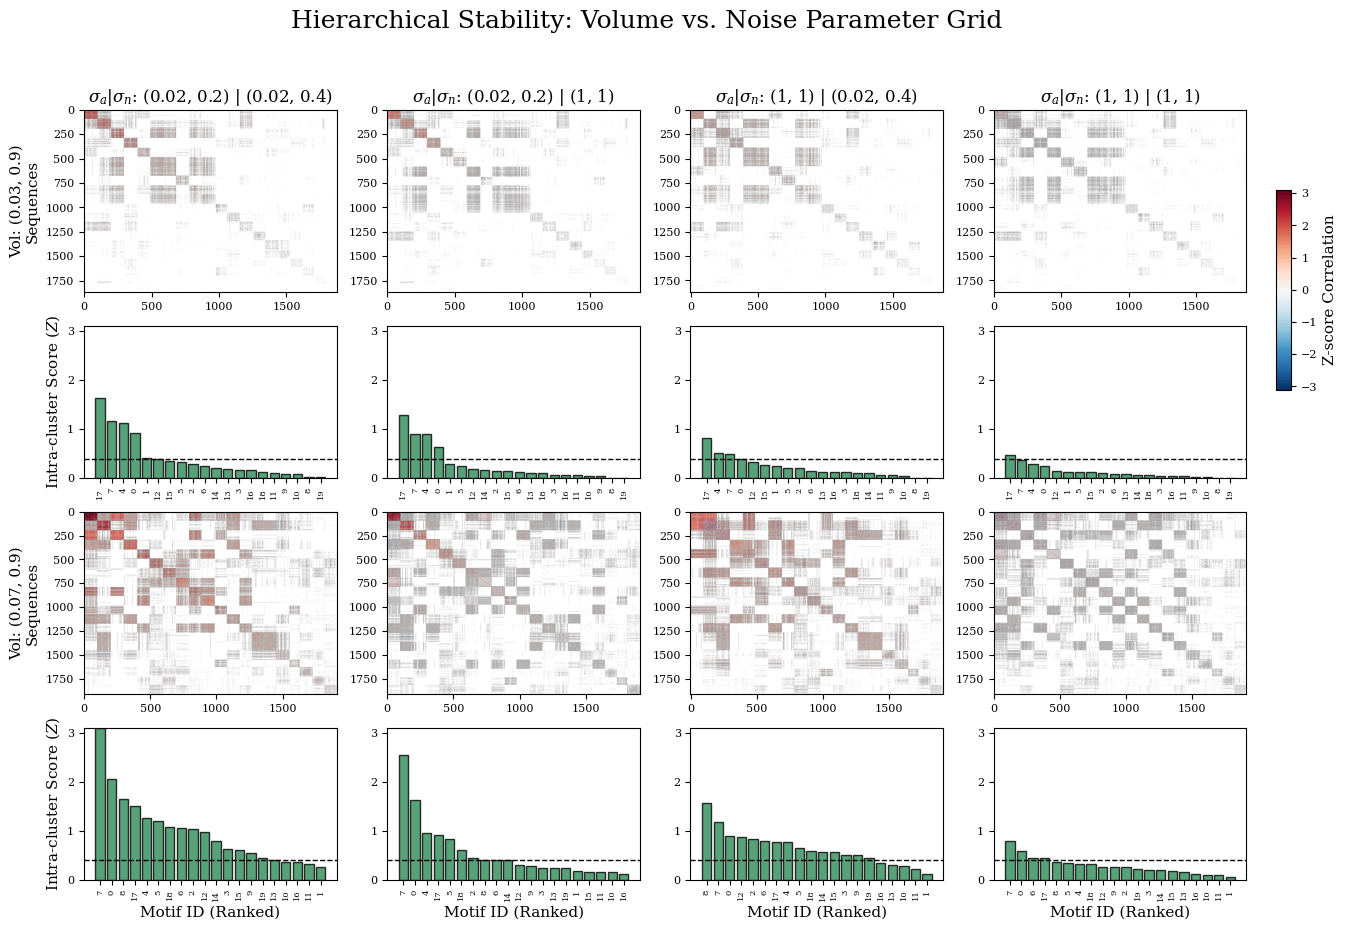

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mats_and_bars_sorted(all_results):
    """
    all_results: Dict where keys are volume strings and values are lists of 4 noise dicts
    """
    v_keys = list(all_results.keys())
    n_vols = len(v_keys)
    n_cols = 4  # The 4 noise combinations
    
    # Grid: 2 rows (Matrix + Bar) per Volume
    fig, axes = plt.subplots(n_vols * 2, n_cols, figsize=(15, 5 * n_vols), 
                             gridspec_kw={'height_ratios': [1.2, 1] * n_vols})

    # Global color scaling for Z-matrices
    all_zmats = [d['zmat'] for v in v_keys for d in all_results[v]]
    all_scores = [d['scores'] for v in v_keys for d in all_results[v]]
    global_max_z = np.nanmax([np.nanmax(np.abs(m)) for m in all_scores])

    for v_idx, vol_str in enumerate(v_keys):
        vol_data = all_results[vol_str] # List of 4 noise dicts
        
        # Determine the row indices for this volume
        row_mat = v_idx * 2
        row_bar = v_idx * 2 + 1

        for col_idx in range(n_cols):
            data = vol_data[col_idx]
            zmat = data['zmat']
            lbls = data['labels']
            sorted_motifs = data['motifs']
            
            # --- 1. Reorder Z-Matrix to match the ranked motifs ---
            new_order = []
            for m_id in sorted_motifs:
                idx = np.where(lbls == m_id)[0]
                new_order.extend(idx)
            sorted_zmat = zmat[np.ix_(new_order, new_order)]

            # --- 2. Plot Sorted Z-Matrix (Top Row for this Vol) ---
            ax_top = axes[row_mat, col_idx]
            im = ax_top.imshow(sorted_zmat, aspect='auto', cmap='RdBu_r', 
                               vmin=-global_max_z, vmax=global_max_z)
            
            # Label only the first volume and top row for clarity
            if v_idx == 0:
                ax_top.set_title(f"$\sigma_a | \sigma_n$: {data['params']}", fontsize=12)
            if col_idx == 0:
                ax_top.set_ylabel(f"Vol: {vol_str}\nSequences", fontsize=11,)

            # --- 3. Plot Ranked Error Bars (Bottom Row for this Vol) ---
            ax_bot = axes[row_bar, col_idx]
            x_pos = np.arange(len(data['scores']))
            
            ax_bot.bar(x_pos, data['scores'], color='seagreen', alpha=0.8, edgecolor='black')
            ax_bot.set_ylim(0, global_max_z)
            
            ax_bot.set_xticks(x_pos)
            ax_bot.set_xticklabels(sorted_motifs, rotation=90, fontsize=6)
            ax_bot.axhline(0.4, color='black', linestyle='dashed')
            
            if col_idx == 0:
                ax_bot.set_ylabel('Intra-cluster Score ($Z$)')
            if v_idx == n_vols - 1:
                ax_bot.set_xlabel('Motif ID (Ranked)')

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.6, 0.01, 0.2])
    fig.colorbar(im, cax=cbar_ax, label='Z-score Correlation')
    
    plt.suptitle('Hierarchical Stability: Volume vs. Noise Parameter Grid', fontsize=18)
    plt.show()

plot_mats_and_bars_sorted(all_results)